# Backcast Engine — Tutorial

**Backcasting** estimates what the returns of short-history assets *would have been* during periods before they existed, by conditioning on the contemporaneous returns of long-history assets with known factor relationships.  The fundamental problem is that asset universes with unequal history lengths produce an incomplete returns matrix: rows before the short-history assets' start dates are filled with NaN.  Naively computing a sample covariance on the overlap period discards information and biases portfolio construction toward the oldest assets.

This library implements three statistical models — **EM (Stambaugh 1997)**, **Kalman filter (time-varying betas)**, and **Hidden Markov Model (regime-switching)** — plus a **multiple imputation** framework that honestly propagates the uncertainty introduced by the backcasting step into downstream quantities like covariance estimates, uncertainty ellipses, and backtest results.

Run this notebook top-to-bottom to walk through the full workflow from raw data to portfolio-ready outputs.

## Section 1 — Introduction & Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, importlib, warnings
from pathlib import Path

# Auto-discover src/ so the notebook runs without pip install.
# Searches the notebook's directory and its parents for backcast/src.
if importlib.util.find_spec('backcast') is None:
    for _p in [Path.cwd()] + list(Path.cwd().parents):
        _src = _p / 'src'
        if (_src / 'backcast' / '__init__.py').exists():
            sys.path.insert(0, str(_src))
            print(f'Added {_src} to sys.path (no pip install needed)')
            break

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

SEED = 42
RNG  = np.random.default_rng(SEED)

# Backcast library imports
try:
    import backcast
    print(f"backcast version: {getattr(backcast, '__version__', 'dev')}")
except ImportError as e:
    print(f"ERROR: {e}\nRun `pip install -e .` from backcast_engine/ first.")
    raise

from backcast.data.loader import build_backcast_dataset
from backcast.models.em_stambaugh import em_stambaugh

try:
    from backcast.models.kalman_tvp import fit_kalman_all, kalman_impute
    KALMAN_AVAILABLE = True
except ImportError:
    KALMAN_AVAILABLE = False
    print("⚠️  KalmanTVP not available — Section 4 will be skipped")

try:
    from backcast.models.regime_hmm import fit_and_select_hmm, compute_regime_params
    HMM_AVAILABLE = True
except ImportError:
    HMM_AVAILABLE = False
    print("⚠️  RegimeHMM not available — Section 5 will be skipped")

from backcast.imputation.single_impute import single_impute
from backcast.imputation.multiple_impute import multiple_impute, combine_estimates

print("All imports OK.")

backcast version: dev
All imports OK.


In [2]:
def generate_tutorial_data(
    seed: int = 42,
    n_long: int = 5,
    n_short: int = 3,
    total_days: int = 5000,
    short_start_day: int = 3000,
) -> tuple[pd.DataFrame, dict]:
    """
    Generate synthetic returns for the tutorial.

    5 long-history assets (all 5000 days), 3 short-history assets
    (starting at day 3000). Uses a known factor-model covariance structure
    so Section 3 can compare EM estimates to ground truth.

    Returns
    -------
    df : pd.DataFrame
        Returns matrix with NaN for short assets before their start date.
    truth : dict
        Ground-truth parameters (mu, sigma, beta, cond_cov).
    """
    rng = np.random.default_rng(seed)
    n_total = n_long + n_short

    # Build a factor-model covariance: Σ = B B^T + D
    # 3 latent factors, moderate loadings
    n_factors = 3
    B = rng.standard_normal((n_total, n_factors)) * 0.01  # daily scale
    D = np.diag(rng.uniform(0.0001, 0.0004, n_total))     # idiosyncratic
    sigma_true = B @ B.T + D
    sigma_true = 0.5 * (sigma_true + sigma_true.T)         # symmetrise

    # Small non-zero daily means
    mu_true = rng.uniform(-0.0001, 0.0003, n_total)

    # Draw full history
    chol = np.linalg.cholesky(sigma_true)
    returns_full = mu_true + (chol @ rng.standard_normal((n_total, total_days))).T

    # Build date index (business days)
    dates = pd.bdate_range('2000-01-03', periods=total_days)

    long_names  = [f"LONG_{i+1}"  for i in range(n_long)]
    short_names = [f"SHORT_{i+1}" for i in range(n_short)]
    all_names   = long_names + short_names

    df = pd.DataFrame(returns_full, index=dates, columns=all_names)

    # Mask short assets before their start day
    df.iloc[:short_start_day, n_long:] = np.nan

    # Ground-truth conditional params (short | long)
    S_OO = sigma_true[:n_long, :n_long]
    S_MO = sigma_true[n_long:, :n_long]
    S_MM = sigma_true[n_long:, n_long:]
    beta_true = S_MO @ np.linalg.inv(S_OO)       # (n_short, n_long)
    cond_cov_true = S_MM - beta_true @ S_OO @ beta_true.T

    truth = dict(
        mu=mu_true,
        sigma=sigma_true,
        beta=beta_true,
        cond_cov=cond_cov_true,
        long_names=long_names,
        short_names=short_names,
        short_start_day=short_start_day,
        total_days=total_days,
    )
    return df, truth


print("generate_tutorial_data() defined.")

generate_tutorial_data() defined.


## Section 2 — Loading & Inspecting Data

The backcast engine expects a returns matrix with shape `(T, N)` where:
- Rows are trading dates (a `DatetimeIndex`).
- Columns are asset names.
- Values are **daily simple returns** (not log-returns, not prices).
- Short-history assets have a **contiguous block of NaN at the start**, then continuous non-NaN data.  This is called *monotone missingness* — the library will raise an error for mid-series gaps.

If you have a CSV, load it with `backcast.data.loader.load_backcast_dataset('path/to/returns.csv')`.  Below we generate synthetic data so the notebook is self-contained.

In [3]:
# ── Cell 2-1  Generate / load data ──────────────────────────────────────────
CSV_PATH = None   # set to 'path/to/returns.csv' to use real data

if CSV_PATH is not None:
    from backcast.data.loader import load_backcast_dataset
    dataset = load_backcast_dataset(CSV_PATH)
    truth   = None
    print(f"Loaded from CSV: {CSV_PATH}")
else:
    raw_returns, truth = generate_tutorial_data(seed=SEED)
    dataset = build_backcast_dataset(raw_returns)
    print("Using inline synthetic data (no CSV_PATH set).")

print(f"\nReturns shape : {dataset.returns_full.shape}")
print(f"Date range    : {dataset.returns_full.index[0].date()} → {dataset.returns_full.index[-1].date()}")
print(f"Missing values: {dataset.returns_full.isna().sum().sum():,}")

Using inline synthetic data (no CSV_PATH set).

Returns shape : (5000, 8)
Date range    : 2000-01-03 → 2019-03-01
Missing values: 9,000


In [4]:
# ── Cell 2-2  Inspect the BackcastDataset ───────────────────────────────────
print("BackcastDataset summary")
print("=" * 50)
print(f"Long-history assets  ({dataset.n_long}): {dataset.long_assets}")
print(f"Short-history assets ({dataset.n_short}): {dataset.short_assets}")
print()
print(f"Overlap start  : {dataset.overlap_start.date() if dataset.overlap_start else 'N/A'}")
print(f"Overlap end    : {dataset.overlap_end.date()   if dataset.overlap_end   else 'N/A'}")
print(f"Overlap length : {dataset.overlap_length:,} trading days ({dataset.overlap_length/252:.1f} years)")
print()
print(f"Backcast start : {dataset.backcast_start.date() if dataset.backcast_start else 'N/A'}")
print(f"Backcast end   : {dataset.backcast_end.date()   if dataset.backcast_end   else 'N/A'}")
print(f"Backcast length: {dataset.backcast_length:,} trading days ({dataset.backcast_length/252:.1f} years)")
print()
print("Short-asset start indices:")
for asset, idx in dataset.short_start_indices.items():
    date = dataset.returns_full.index[idx].date()
    print(f"  {asset}: row {idx:,} ({date})")

BackcastDataset summary
Long-history assets  (5): ['LONG_1', 'LONG_2', 'LONG_3', 'LONG_4', 'LONG_5']
Short-history assets (3): ['SHORT_1', 'SHORT_2', 'SHORT_3']

Overlap start  : 2011-07-04
Overlap end    : 2019-03-01
Overlap length : 2,000 trading days (7.9 years)

Backcast start : 2000-01-03
Backcast end   : 2011-07-01
Backcast length: 3,000 trading days (11.9 years)

Short-asset start indices:
  SHORT_1: row 3,000 (2011-07-04)
  SHORT_2: row 3,000 (2011-07-04)
  SHORT_3: row 3,000 (2011-07-04)


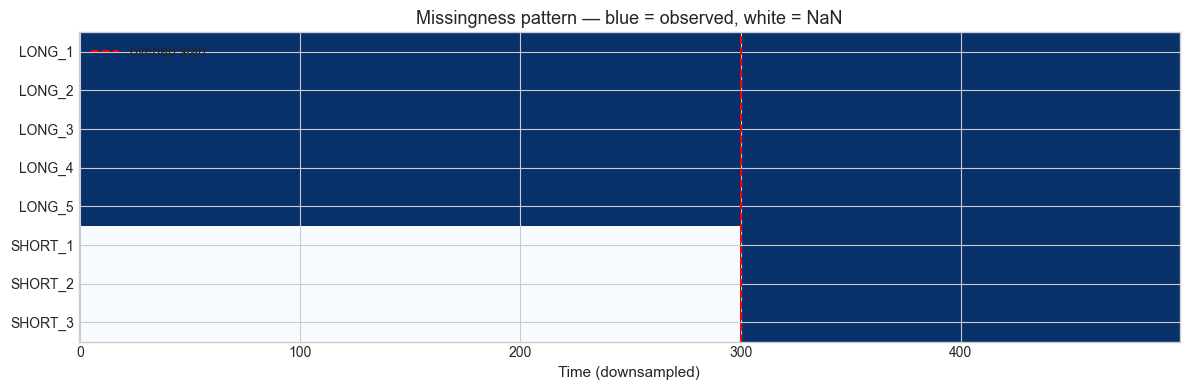


Fraction observed per asset:
  LONG_1      100.0%  ████████████████████████████████████████
  LONG_2      100.0%  ████████████████████████████████████████
  LONG_3      100.0%  ████████████████████████████████████████
  LONG_4      100.0%  ████████████████████████████████████████
  LONG_5      100.0%  ████████████████████████████████████████
  SHORT_1     40.0%  ████████████████
  SHORT_2     40.0%  ████████████████
  SHORT_3     40.0%  ████████████████


In [5]:
# ── Cell 2-3  Missingness heatmap ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

observed = (~dataset.returns_full.isna()).astype(float)
step   = max(1, len(observed) // 500)
obs_ds = observed.iloc[::step]   # shape (T_down, N)

# imshow: rows = assets (y-axis), cols = time (x-axis)
ax.imshow(
    obs_ds.T.values,
    aspect='auto',
    cmap='Blues', vmin=0, vmax=1,
    origin='upper',
    interpolation='nearest',
)

boundary_row = dataset.backcast_length // step
ax.axvline(boundary_row, color='red', lw=1.5, ls='--', label='overlap start')

ax.set_yticks(np.arange(dataset.n_total))
ax.set_yticklabels(dataset.asset_names)
ax.set_xlabel('Time (downsampled)')
ax.set_title('Missingness pattern — blue = observed, white = NaN')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

obs_frac = (~dataset.returns_full.isna()).mean()
print("\nFraction observed per asset:")
for asset, frac in obs_frac.items():
    bar = '█' * int(frac * 40)
    print(f"  {asset:<10}  {frac:.1%}  {bar}")

Overlap period EDA
         Ann. Mean (%)  Ann. Vol (%)  Skewness  Exc. Kurtosis
LONG_1           -9.27         35.34     0.059          0.094
LONG_2          -11.81         45.50    -0.013          0.037
LONG_3            7.91         25.68     0.003         -0.064
LONG_4           27.15         29.66    -0.068          0.070
LONG_5           23.23         26.74    -0.005         -0.114
SHORT_1         -10.93         35.10     0.009         -0.088
SHORT_2          -8.64         31.33     0.045          0.064
SHORT_3         -14.84         39.36    -0.013          0.033


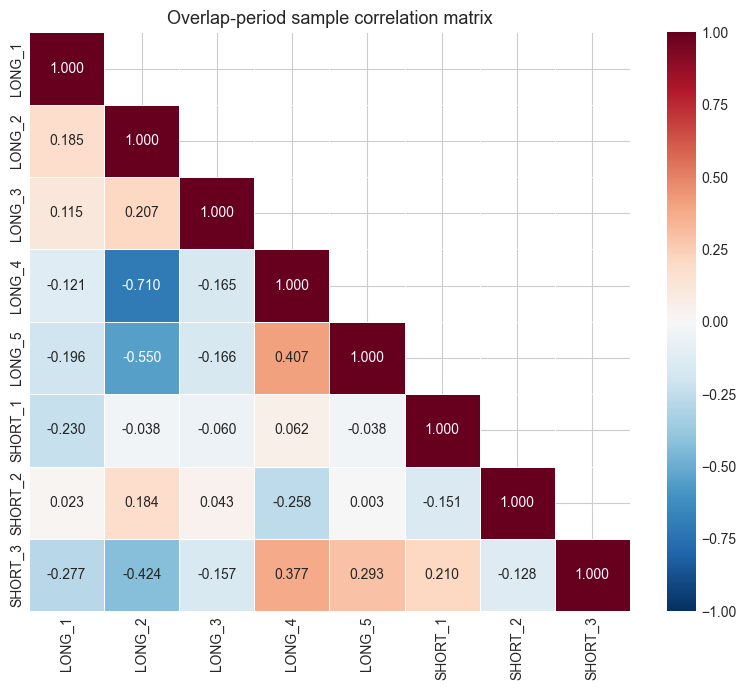

In [6]:
# ── Cell 2-4  Basic EDA on the overlap period ────────────────────────────────
overlap = dataset.overlap_matrix

ann_mean = overlap.mean() * 252
ann_vol  = overlap.std()  * np.sqrt(252)
skew     = overlap.skew()
kurt     = overlap.kurt()   # excess kurtosis

eda = pd.DataFrame({
    'Ann. Mean (%)':  (ann_mean * 100).round(2),
    'Ann. Vol (%)':   (ann_vol  * 100).round(2),
    'Skewness':       skew.round(3),
    'Exc. Kurtosis':  kurt.round(3),
})
print("Overlap period EDA")
print(eda.to_string())

# Correlation heatmap
corr = overlap.corr()
fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax,
    mask=mask,
)
ax.set_title('Overlap-period sample correlation matrix')
plt.tight_layout()
plt.show()

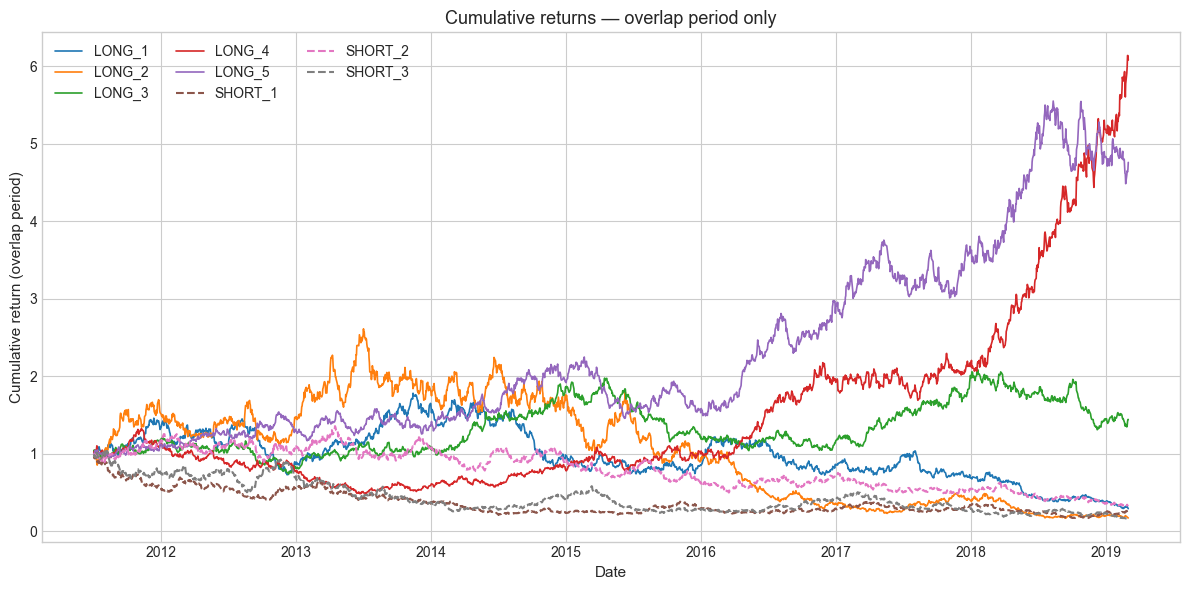

In [7]:
# ── Cell 2-5  Cumulative returns in the overlap period ───────────────────────
cum_ret = (1 + overlap).cumprod()

palette = plt.cm.tab10.colors
long_c  = palette[:dataset.n_long]
short_c = palette[dataset.n_long:dataset.n_long + dataset.n_short]

fig, ax = plt.subplots(figsize=(12, 6))
for i, col in enumerate(dataset.long_assets):
    ax.plot(cum_ret.index, cum_ret[col], color=long_c[i], lw=1.2, label=col)
for i, col in enumerate(dataset.short_assets):
    ax.plot(cum_ret.index, cum_ret[col], color=short_c[i], lw=1.5, ls='--', label=col)

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative return (overlap period)')
ax.set_title('Cumulative returns — overlap period only')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## Section 3 — Model 1: EM Algorithm (Stambaugh 1997)

The **EM algorithm** iteratively estimates the full unconditional mean $\mu$ and covariance $\Sigma$ from a matrix with monotone missing data.

**E-step**: For each row with missing entries, compute the conditional expectation $E[R_M \mid R_O, \mu, \Sigma]$ and the conditional covariance $\Sigma_{M|O} = \Sigma_{MM} - \Sigma_{MO}\Sigma_{OO}^{-1}\Sigma_{OM}$.  This fills the missing block with plausible values given the observed data in that row.

**M-step**: Re-estimate $\mu$ and $\Sigma$ from the filled-in matrix.  The critical addition is a **variance correction**: adding $\Sigma_{M|O}$ to the sufficient statistics for every row with missing data.  Without it, the imputed entries are treated as noise-free observations, causing the covariance of short-history assets to be underestimated.

The procedure is iterated to convergence, measured by the Frobenius norm $\|\Sigma_{k+1} - \Sigma_k\|_F < \text{tol}$.  The output is the maximum-likelihood estimate of $(\mu, \Sigma)$ under the multivariate Gaussian model.  Reference: Stambaugh (1997), *JFE* 45(3).

In [8]:
# ── Cell 3-1  Fit the EM model ───────────────────────────────────────────────
try:
    em_result = em_stambaugh(
        dataset.returns_full,
        max_iter=500,
        tolerance=1e-8,
        track_loglikelihood=True,
    )
    print(f"Converged     : {em_result.converged}")
    print(f"Iterations    : {em_result.n_iter}")
    print(f"Final ΔΣ (Frob): {em_result.final_delta:.3e}")
    print(f"Asset order   : {em_result.asset_order}")
except Exception as exc:
    print(f"⚠️  EM failed: {exc}")
    em_result = None

Converged     : True
Iterations    : 14
Final ΔΣ (Frob): 9.804e-09
Asset order   : ['LONG_1', 'LONG_2', 'LONG_3', 'LONG_4', 'LONG_5', 'SHORT_1', 'SHORT_2', 'SHORT_3']


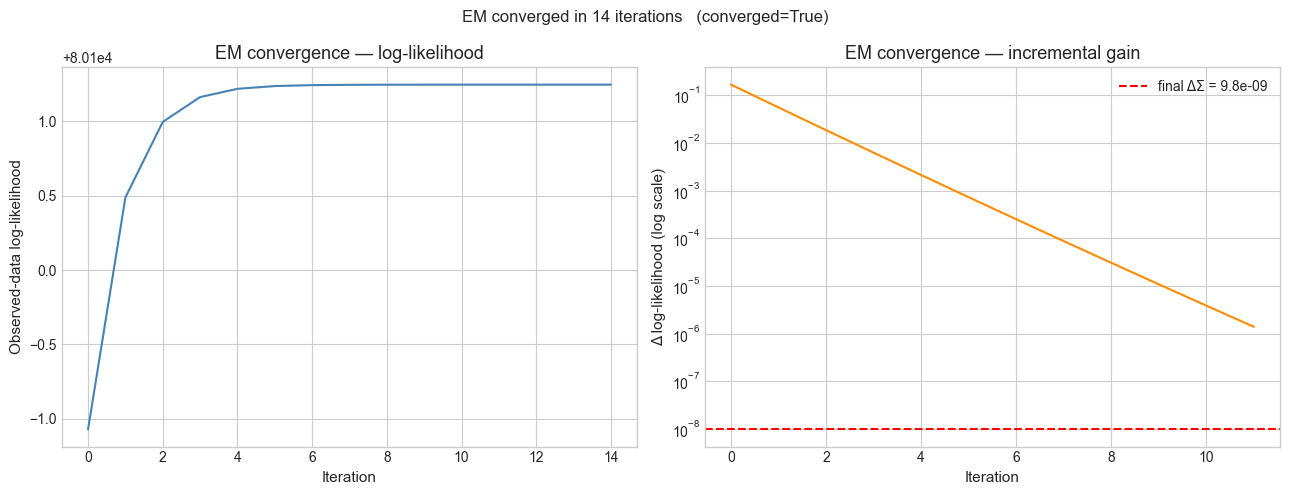

In [9]:
# ── Cell 3-2  Convergence plot ───────────────────────────────────────────────
if em_result is not None and em_result.log_likelihood_trace:
    ll = em_result.log_likelihood_trace
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(ll, lw=1.5, color='steelblue')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Observed-data log-likelihood')
    axes[0].set_title('EM convergence — log-likelihood')

    # Increments after iteration 2 (first step is large by construction)
    increments = np.diff(ll[2:])
    axes[1].semilogy(increments.clip(min=1e-15), lw=1.5, color='darkorange')
    axes[1].axhline(em_result.final_delta, ls='--', color='red', label=f'final ΔΣ = {em_result.final_delta:.1e}')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Δ log-likelihood (log scale)')
    axes[1].set_title('EM convergence — incremental gain')
    axes[1].legend()

    plt.suptitle(
        f'EM converged in {em_result.n_iter} iterations   '
        f'(converged={em_result.converged})',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No log-likelihood trace available (em_result is None or trace empty).")

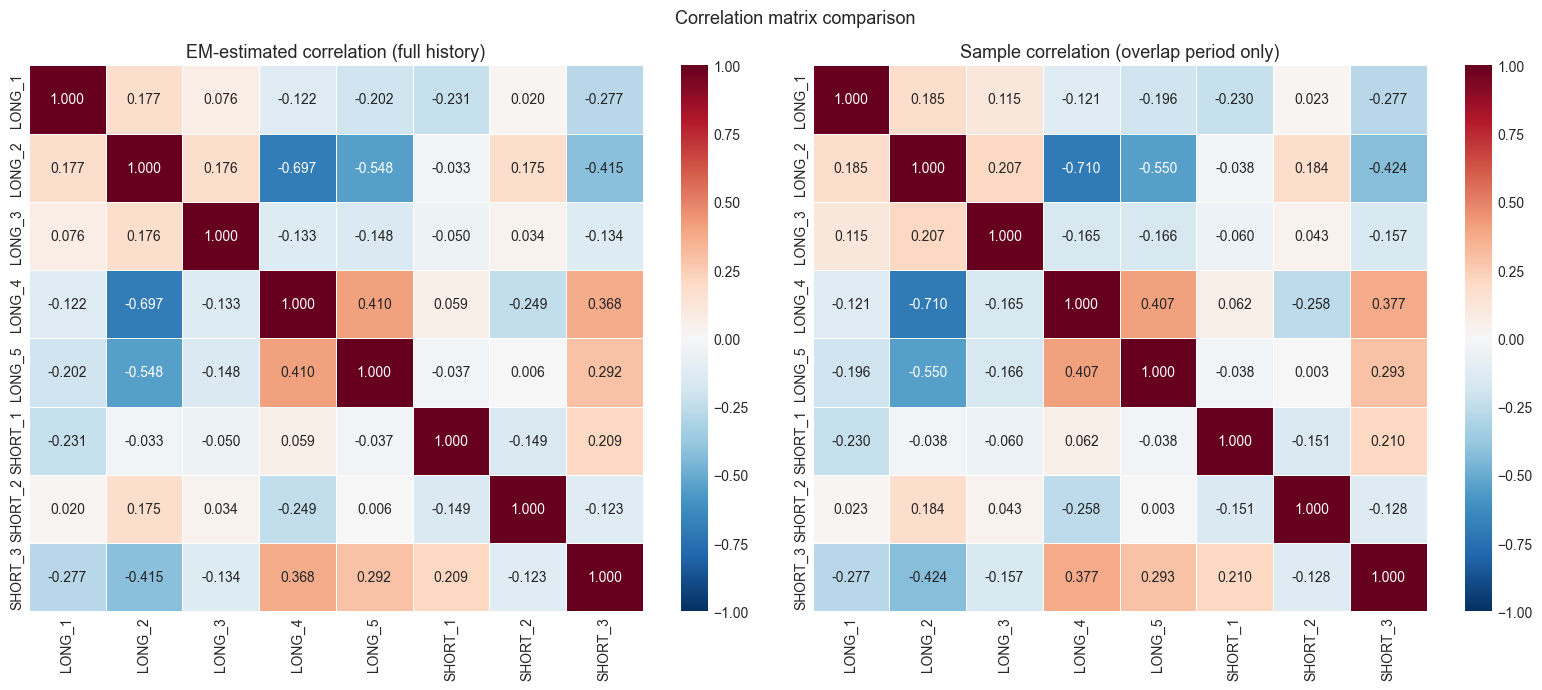

The EM estimate uses the full long-asset history, so correlations
involving long assets are typically better-conditioned than the overlap-only sample.


In [10]:
# ── Cell 3-3  Estimated vs overlap-sample correlation matrices ────────────────
if em_result is not None:
    # EM full-sample correlation
    vol = np.sqrt(np.diag(em_result.sigma))
    em_corr = em_result.sigma / np.outer(vol, vol)
    em_corr_df = pd.DataFrame(em_corr, index=em_result.asset_order, columns=em_result.asset_order)

    # Overlap-period sample correlation
    sample_corr = dataset.overlap_matrix.corr()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    common_kw = dict(annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, linewidths=0.5)

    sns.heatmap(em_corr_df,   ax=axes[0], **common_kw)
    axes[0].set_title('EM-estimated correlation (full history)')

    sns.heatmap(sample_corr, ax=axes[1], **common_kw)
    axes[1].set_title('Sample correlation (overlap period only)')

    plt.suptitle('Correlation matrix comparison', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("The EM estimate uses the full long-asset history, so correlations")
    print("involving long assets are typically better-conditioned than the overlap-only sample.")

In [11]:
# ── Cell 3-4  Conditional parameters ────────────────────────────────────────
if em_result is not None:
    cp = em_result.conditional_params
    long_names  = [em_result.asset_order[i] for i in cp.observed_cols]
    short_names = [em_result.asset_order[i] for i in cp.missing_cols]

    # Beta matrix: short-on-long factor loadings
    beta_df = pd.DataFrame(cp.beta, index=short_names, columns=long_names)
    print("Regression coefficients β = Σ₂₁ Σ₁₁⁻¹  (short assets × long assets)")
    print("Interpretation: each row gives the factor loadings of a short asset on the long-history factors.")
    print(beta_df.to_string(float_format=lambda x: f"{x:+.6f}"))

    print()
    print("Conditional covariance Σ₂₂|₁ (residual uncertainty after conditioning on long assets):")
    cond_cov_df = pd.DataFrame(cp.cond_cov, index=short_names, columns=short_names)
    print(cond_cov_df.to_string(float_format=lambda x: f"{x:.8f}"))

    print()
    print("Largest absolute loadings (top 5):")
    beta_flat = beta_df.stack().abs().sort_values(ascending=False)
    for (short, long), val in beta_flat.head(5).items():
        print(f"  {short} → {long}: {val:.6f}")

Regression coefficients β = Σ₂₁ Σ₁₁⁻¹  (short assets × long assets)
Interpretation: each row gives the factor loadings of a short asset on the long-history factors.
           LONG_1    LONG_2    LONG_3    LONG_4    LONG_5
SHORT_1 -0.238719 +0.002313 -0.055605 +0.092975 -0.160556
SHORT_2 +0.005042 +0.056100 +0.010326 -0.277111 +0.184665
SHORT_3 -0.221595 -0.206542 -0.077425 +0.203900 +0.076092

Conditional covariance Σ₂₂|₁ (residual uncertainty after conditioning on long assets):
            SHORT_1     SHORT_2     SHORT_3
SHORT_1  0.00045587 -0.00005389  0.00007907
SHORT_2 -0.00005389  0.00035684 -0.00001866
SHORT_3  0.00007907 -0.00001866  0.00046859

Largest absolute loadings (top 5):
  SHORT_2 → LONG_4: 0.277111
  SHORT_1 → LONG_1: 0.238719
  SHORT_3 → LONG_1: 0.221595
  SHORT_3 → LONG_2: 0.206542
  SHORT_3 → LONG_4: 0.203900


Frobenius norm |Σ_EM − Σ_true|_F : 0.000076
Relative Frobenius error          : 4.5006%
The EM recovered the true covariance within 4.50% relative error.


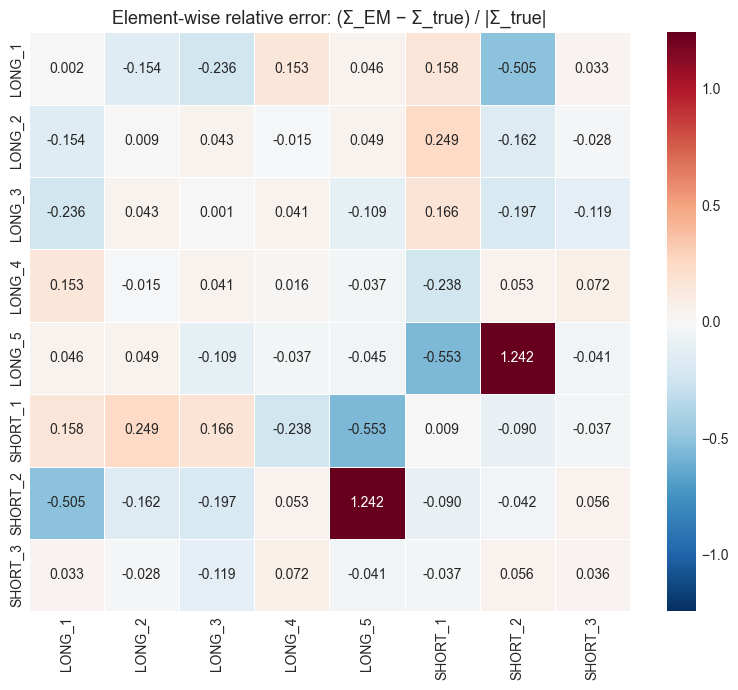


Beta comparison (EM vs truth):
Max absolute beta error: 0.041091
Mean absolute beta error: 0.016969


In [12]:
# ── Cell 3-5  Ground-truth comparison (synthetic data only) ──────────────────
if em_result is not None and truth is not None:
    sigma_true = truth['sigma']
    sigma_em   = em_result.sigma

    frob_abs = np.linalg.norm(sigma_em - sigma_true, 'fro')
    frob_rel = frob_abs / np.linalg.norm(sigma_true, 'fro')
    print(f"Frobenius norm |Σ_EM − Σ_true|_F : {frob_abs:.6f}")
    print(f"Relative Frobenius error          : {frob_rel:.4%}")
    print(f"The EM recovered the true covariance within {frob_rel:.2%} relative error.")

    # Element-wise relative error heatmap
    rel_err = (sigma_em - sigma_true) / (np.abs(sigma_true) + 1e-12)
    rel_err_df = pd.DataFrame(
        rel_err,
        index=em_result.asset_order,
        columns=em_result.asset_order,
    )

    max_err = np.abs(rel_err).max()
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        rel_err_df, annot=True, fmt='.3f', cmap='RdBu_r',
        vmin=-max_err, vmax=max_err, center=0,
        linewidths=0.5, ax=ax,
    )
    ax.set_title('Element-wise relative error: (Σ_EM − Σ_true) / |Σ_true|')
    plt.tight_layout()
    plt.show()

    # Beta comparison
    print("\nBeta comparison (EM vs truth):")
    n_short = len(truth['short_names'])
    n_long  = len(truth['long_names'])
    beta_true_df = pd.DataFrame(
        truth['beta'], index=truth['short_names'], columns=truth['long_names']
    )
    cp = em_result.conditional_params
    long_nm  = [em_result.asset_order[i] for i in cp.observed_cols]
    short_nm = [em_result.asset_order[i] for i in cp.missing_cols]
    beta_em_df = pd.DataFrame(cp.beta, index=short_nm, columns=long_nm)

    beta_err = beta_em_df.values - beta_true_df.values
    print(f"Max absolute beta error: {np.abs(beta_err).max():.6f}")
    print(f"Mean absolute beta error: {np.abs(beta_err).mean():.6f}")
elif truth is None:
    print("Ground-truth comparison only available for synthetic data (CSV_PATH=None).")
else:
    print("EM result not available — skipping ground-truth comparison.")

## Section 4 — Model 2: Kalman Filter (Time-Varying Betas)

The **Kalman filter TVP model** estimates *time-varying* regression coefficients (betas) of each short-history asset on the long-history factors.  Unlike the EM, which assumes the relationship is constant over time, the Kalman model allows the loadings to drift slowly — following a random-walk state equation $\beta_t = \beta_{t-1} + \eta_t$.

The observation equation is $r_{\text{short},t} = Z_t \beta_t + \varepsilon_t$, where $Z_t = [1, r_{\text{long},t}]$ is the design row and $\varepsilon_t \sim N(0, H)$ is the observation noise.  The RTS smoother runs backward through the filter output to produce the best estimate of $\beta_t$ given the *full* overlap window — these smoothed betas are more stable than the filtered (one-sided) estimates.

The **backcast loading** is fixed at the earliest smoothed state and applied unchanged backward through the pre-history period — the model does *not* extrapolate the drift.

In [13]:
# ── Cell 4-1  Fit the Kalman TVP model ──────────────────────────────────────
if KALMAN_AVAILABLE:
    try:
        kalman_result = fit_kalman_all(
            dataset.overlap_matrix,
            long_assets=dataset.long_assets,
            short_assets=dataset.short_assets,
            use_smoother=True,
            backcast_beta_method='earliest_smoothed',
        )
        print('Kalman TVP fitted successfully.')
        print(f'Short assets modelled: {kalman_result.short_assets}')
        print(f'Long factors used   : {kalman_result.long_assets}')
        print()
        print('Per-asset log-likelihoods:')
        for name, res in kalman_result.per_asset.items():
            print(f'  {name}: log-L = {res.log_likelihood:,.1f}   H = {res.residual_variance:.6f}')
    except Exception as exc:
        print(f'⚠️  Kalman fit failed: {exc}')
        kalman_result = None
else:
    kalman_result = None
    print('Skipped — KalmanTVP not yet implemented')

Kalman TVP fitted successfully.
Short assets modelled: ['SHORT_1', 'SHORT_2', 'SHORT_3']
Long factors used   : ['LONG_1', 'LONG_2', 'LONG_3', 'LONG_4', 'LONG_5']

Per-asset log-likelihoods:
  SHORT_1: log-L = 4,781.1   H = 0.000457
  SHORT_2: log-L = 5,022.1   H = 0.000358
  SHORT_3: log-L = 4,755.8   H = 0.000470


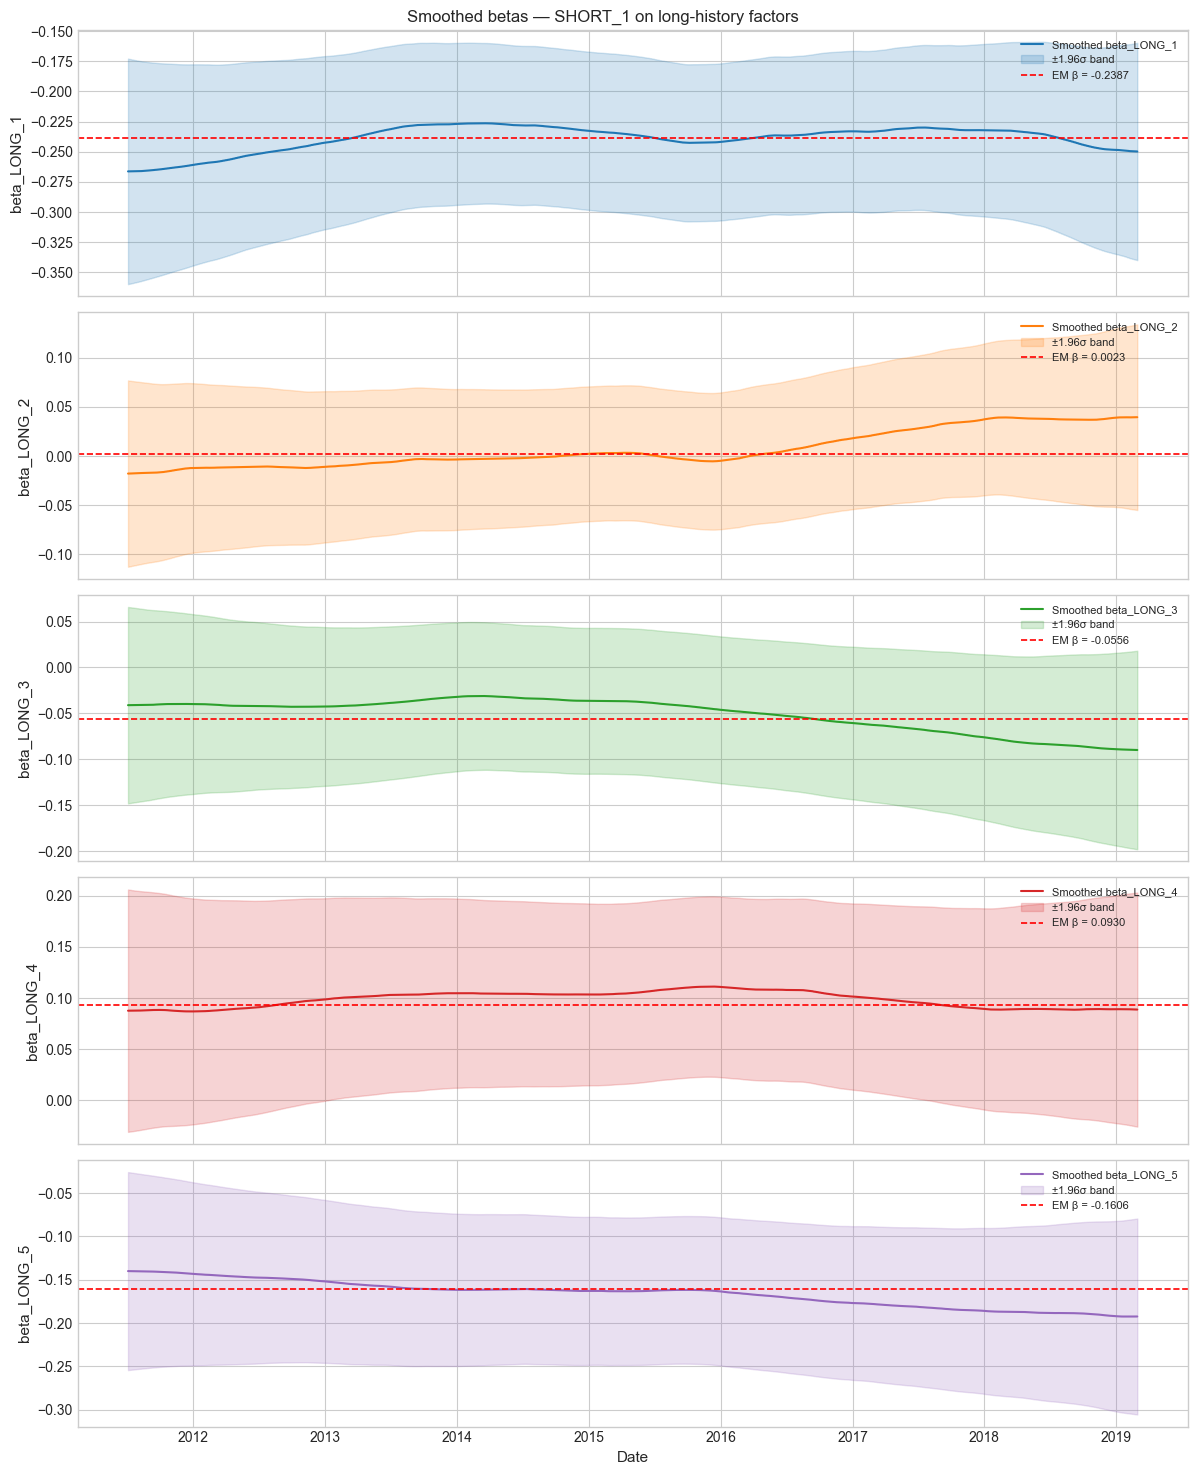

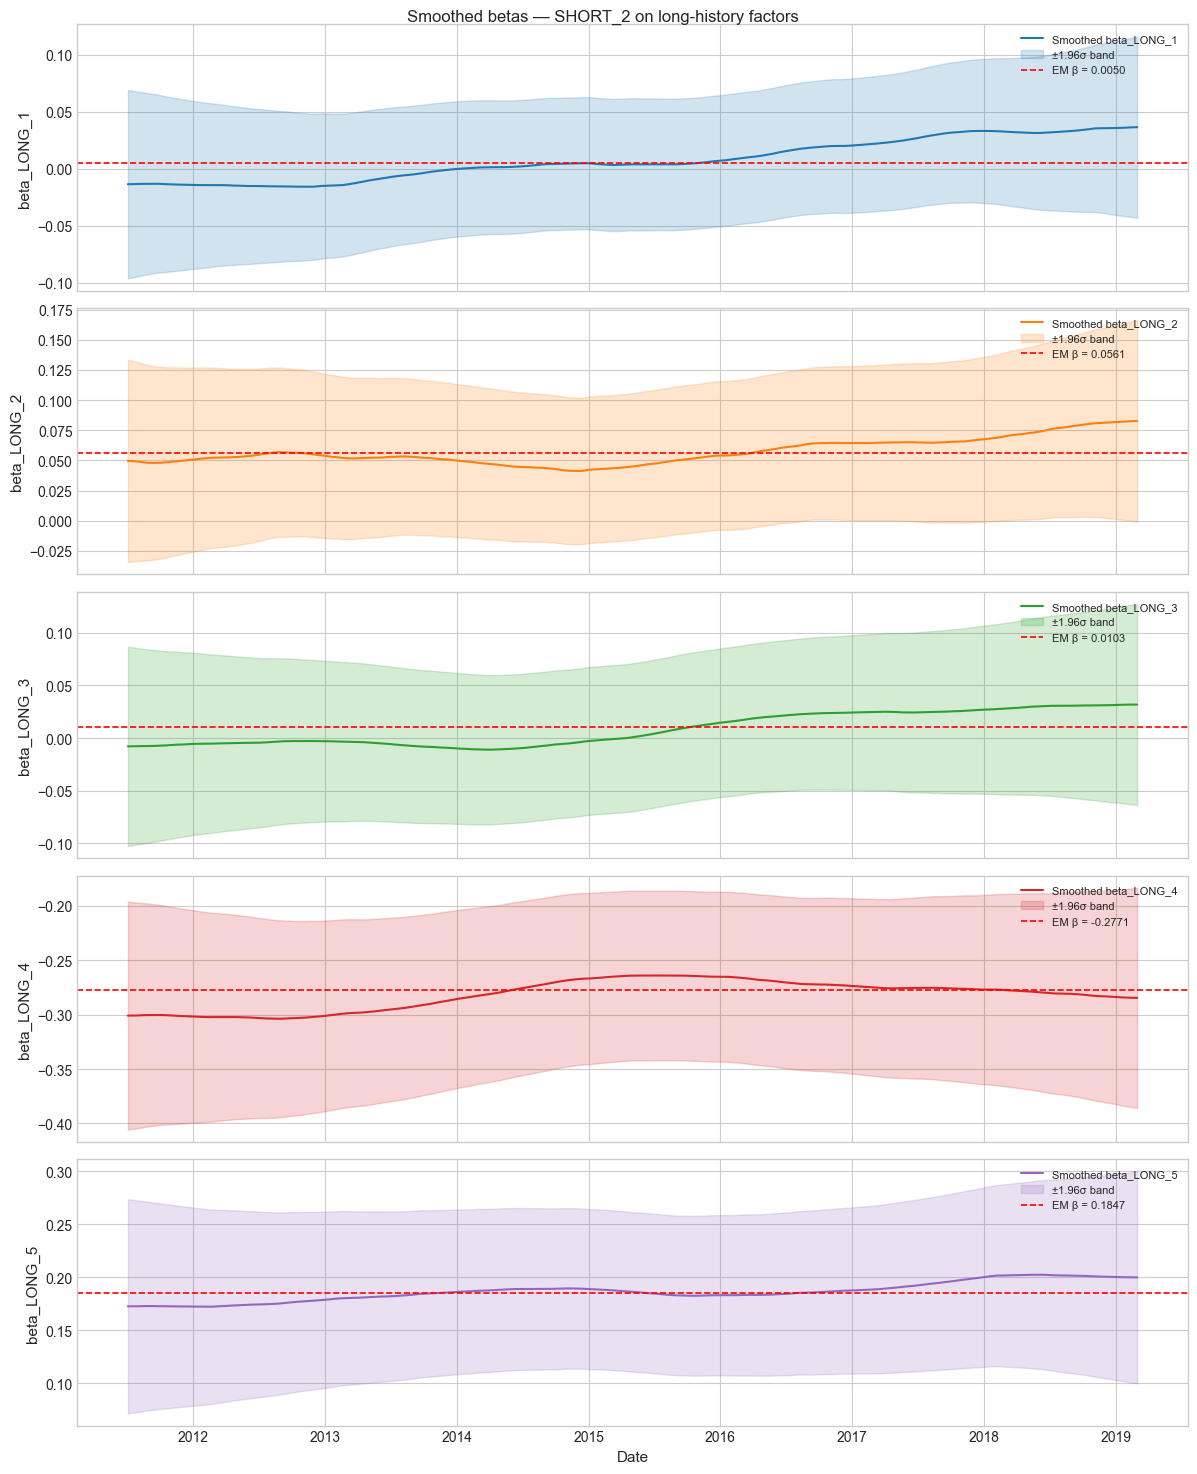

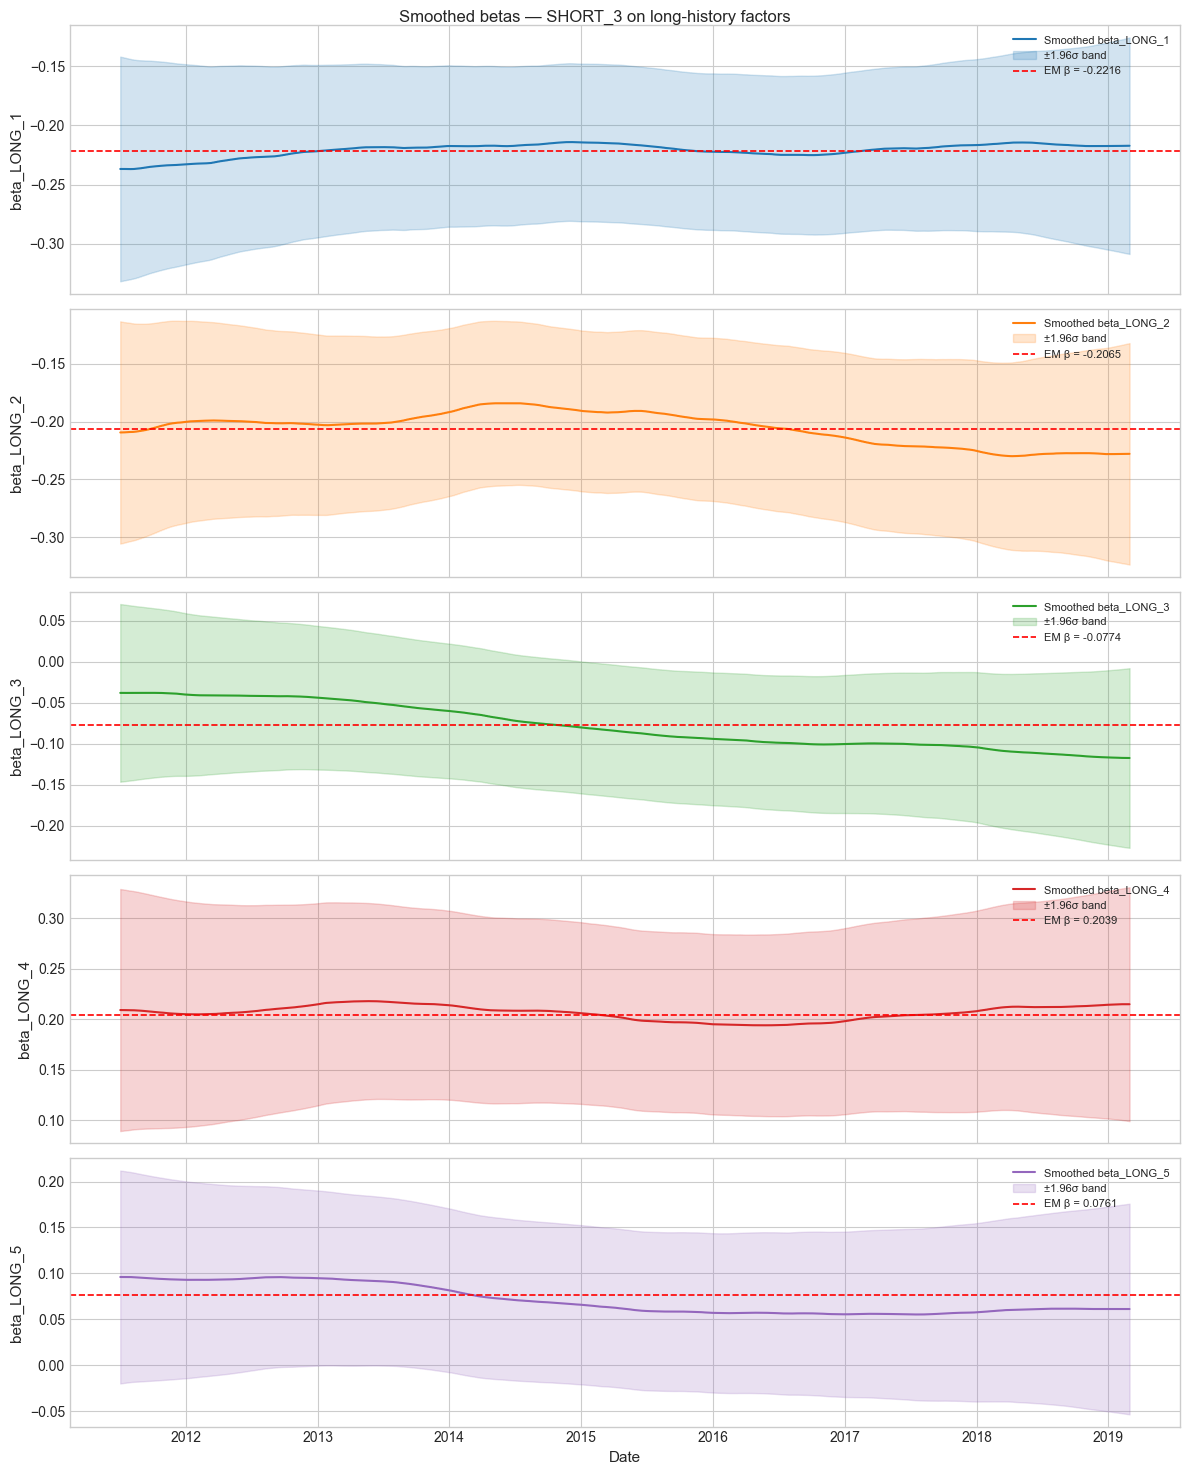

In [14]:
# ── Cell 4-2  Smoothed betas over time with confidence bands ─────────────────
if kalman_result is not None:
    palette = plt.cm.tab10.colors

    for name in kalman_result.short_assets:
        res    = kalman_result.per_asset[name]
        states = kalman_result.smoothed_betas[name]       # (T, K+1) DataFrame
        cov    = res.smoothed_state_cov                   # (T, K+1, K+1)
        std    = np.sqrt(np.diagonal(cov, axis1=1, axis2=2))  # (T, K+1)

        beta_cols = [c for c in states.columns if c.startswith('beta_')]
        n_betas   = len(beta_cols)

        fig, axes = plt.subplots(n_betas, 1, figsize=(12, 3 * n_betas), sharex=True)
        if n_betas == 1:
            axes = [axes]

        for j, col in enumerate(beta_cols):
            state_idx = list(states.columns).index(col)
            beta_path = states[col].values
            beta_std  = std[:, state_idx]
            dates     = states.index
            ax        = axes[j]

            ax.plot(dates, beta_path, lw=1.5, color=palette[j % 10], label=f'Smoothed {col}')
            ax.fill_between(
                dates,
                beta_path - 1.96 * beta_std,
                beta_path + 1.96 * beta_std,
                alpha=0.2, color=palette[j % 10], label='±1.96σ band',
            )

            # EM constant beta overlay for comparison
            if em_result is not None:
                cp       = em_result.conditional_params
                short_nm = [em_result.asset_order[k] for k in cp.missing_cols]
                long_nm  = [em_result.asset_order[k] for k in cp.observed_cols]
                if name in short_nm:
                    si          = short_nm.index(name)
                    long_factor = col.replace('beta_', '')
                    if long_factor in long_nm:
                        li     = long_nm.index(long_factor)
                        em_val = cp.beta[si, li]
                        ax.axhline(em_val, ls='--', color='red', lw=1.2,
                                   label=f'EM β = {em_val:.4f}')

            ax.set_ylabel(col)
            ax.legend(loc='upper right', fontsize=8)

        axes[-1].set_xlabel('Date')
        fig.suptitle(f'Smoothed betas — {name} on long-history factors', fontsize=12)
        plt.tight_layout()
        plt.show()

In [15]:
# ── Cell 4-3  Compare Kalman earliest betas to EM constant betas ─────────────
if kalman_result is not None and em_result is not None:
    cp       = em_result.conditional_params
    long_nm  = [em_result.asset_order[k] for k in cp.observed_cols]
    short_nm = [em_result.asset_order[k] for k in cp.missing_cols]
    em_beta_df = pd.DataFrame(cp.beta, index=short_nm, columns=long_nm)

    print('Backcast betas: Kalman earliest-smoothed vs EM constant')
    print('=' * 65)
    any_large = False
    for name in kalman_result.short_assets:
        res      = kalman_result.per_asset[name]
        kal_beta = res.backcast_state[1:]    # drop intercept
        em_beta  = em_beta_df.loc[name].values
        print(f'\n{name}:')
        for j, long in enumerate(kalman_result.long_assets):
            diff = kal_beta[j] - em_beta[j]
            flag = '  ← large drift' if abs(diff) > 0.05 else ''
            if flag:
                any_large = True
            print(f'  {long:<10}  Kalman={kal_beta[j]:+.6f}  EM={em_beta[j]:+.6f}  Δ={diff:+.6f}{flag}')

    print()
    if any_large:
        print('⚠  Significant drift detected in some betas. The EM stationarity assumption')
        print('   may be violated. Consider regime-conditional imputation (Section 5).')
    else:
        print('✓  Kalman and EM betas are close — the EM stationarity assumption looks reasonable.')
elif kalman_result is None:
    print('Kalman result not available — skipped.')

Backcast betas: Kalman earliest-smoothed vs EM constant

SHORT_1:
  LONG_1      Kalman=-0.266219  EM=-0.238719  Δ=-0.027501
  LONG_2      Kalman=-0.017798  EM=+0.002313  Δ=-0.020111
  LONG_3      Kalman=-0.041019  EM=-0.055605  Δ=+0.014587
  LONG_4      Kalman=+0.087590  EM=+0.092975  Δ=-0.005385
  LONG_5      Kalman=-0.139960  EM=-0.160556  Δ=+0.020596

SHORT_2:
  LONG_1      Kalman=-0.013682  EM=+0.005042  Δ=-0.018724
  LONG_2      Kalman=+0.049545  EM=+0.056100  Δ=-0.006555
  LONG_3      Kalman=-0.007830  EM=+0.010326  Δ=-0.018156
  LONG_4      Kalman=-0.300904  EM=-0.277111  Δ=-0.023793
  LONG_5      Kalman=+0.172467  EM=+0.184665  Δ=-0.012199

SHORT_3:
  LONG_1      Kalman=-0.236824  EM=-0.221595  Δ=-0.015229
  LONG_2      Kalman=-0.209384  EM=-0.206542  Δ=-0.002843
  LONG_3      Kalman=-0.037814  EM=-0.077425  Δ=+0.039610
  LONG_4      Kalman=+0.209123  EM=+0.203900  Δ=+0.005222
  LONG_5      Kalman=+0.096085  EM=+0.076092  Δ=+0.019993

✓  Kalman and EM betas are close — the EM s

In [16]:
# ── Cell 4-4  Backcast betas used for imputation ─────────────────────────────
if kalman_result is not None:
    print('Backcast loading matrix  (rows = short assets, cols = intercept + long factors)')
    print('These fixed loadings are applied to every row in the backcast period.')
    print('Method: earliest_smoothed — the RTS-smoothed state at t=0 of the overlap window.\n')
    print(kalman_result.backcast_matrix.to_string(float_format=lambda x: f'{x:+.6f}'))
    print()
    print('Alternative: backcast_beta_method="mean_first_k" averages the first K=63')
    print('smoothed states — useful when the earliest date has high posterior variance.')

Backcast loading matrix  (rows = short assets, cols = intercept + long factors)
These fixed loadings are applied to every row in the backcast period.
Method: earliest_smoothed — the RTS-smoothed state at t=0 of the overlap window.

         intercept    LONG_1    LONG_2    LONG_3    LONG_4    LONG_5
SHORT_1  -0.008101 -0.266219 -0.017798 -0.041019 +0.087590 -0.139960
SHORT_2  -0.001964 -0.013682 +0.049545 -0.007830 -0.300904 +0.172467
SHORT_3  -0.003571 -0.236824 -0.209384 -0.037814 +0.209123 +0.096085

Alternative: backcast_beta_method="mean_first_k" averages the first K=63
smoothed states — useful when the earliest date has high posterior variance.


## Section 5 — Model 3: Regime-Switching HMM

The **Hidden Markov Model** detects latent market regimes from the long-history asset returns.  Regimes are canonicalised by total variance so regime 0 is always the calm (low-vol) state and regime $K-1$ is the high-vol (crisis) state.

The model is fitted via log-space Baum-Welch on the **full long-asset history** (always fully observed), giving regime labels across the entire date range — including the backcast period where short assets are missing.  Regime-conditional parameters $(\mu^{(k)}, \Sigma^{(k)})$ are then estimated from the overlap period (where all assets are visible), enabling imputation that respects the market environment at each historical date.

Model complexity $K$ is selected by BIC across $K \in \{2, 3, 4\}$. Lower BIC = better penalised fit.

In [17]:
# ── Cell 5-1  Fit HMM with K=2,3,4 selection by BIC ─────────────────────────
if HMM_AVAILABLE:
    try:
        # Must use fully-observed data: long-asset full history (no NaN)
        long_full = dataset.returns_full[dataset.long_assets]
        hmm_selection = fit_and_select_hmm(
            long_full,
            n_regimes_candidates=(2, 3, 4),
            criterion='bic',
            seed=SEED,
        )
        hmm_result = hmm_selection.best
        print(f'Selected: K={hmm_selection.best_n_regimes} regimes (lowest BIC)')
        print(f'Converged: {hmm_result.converged}  |  Iterations: {hmm_result.n_iter}')
    except Exception as exc:
        print(f'⚠️  HMM fit failed: {exc}')
        hmm_selection = None
        hmm_result    = None
else:
    hmm_selection = None
    hmm_result    = None
    print('Skipped — RegimeHMM not yet implemented')

Selected: K=2 regimes (lowest BIC)
Converged: False  |  Iterations: 200


In [18]:
# ── Cell 5-2  Model selection results and transition matrix ──────────────────
if hmm_selection is not None:
    print('BIC scores by number of regimes (lower = better penalised fit):')
    for k in hmm_selection.candidates:
        r      = hmm_selection.results[k]
        marker = ' ← selected' if k == hmm_selection.best_n_regimes else ''
        print(f'  K={k}:  BIC={r.bic:,.1f}   AIC={r.aic:,.1f}   log-L={r.log_likelihood:,.1f}{marker}')

    K    = hmm_result.n_regimes
    A_df = pd.DataFrame(
        hmm_result.transition_matrix,
        index  =[f'Regime {k}' for k in range(K)],
        columns=[f'→ Regime {k}' for k in range(K)],
    )
    print(f'\nTransition matrix (row = from, col = to):')
    print(A_df.to_string(float_format=lambda x: f'{x:.4f}'))

    print('\nExpected regime durations:')
    diag = np.diag(hmm_result.transition_matrix)
    for k in range(K):
        persist = 1.0 / max(1e-9, 1.0 - diag[k])
        label   = 'calm' if k == 0 else ('crisis' if k == K - 1 else 'transition')
        print(f'  Regime {k} ({label}): {persist:.1f} trading days')

BIC scores by number of regimes (lower = better penalised fit):
  K=2:  BIC=-130,208.6   AIC=-130,488.8   log-L=65,287.4 ← selected
  K=3:  BIC=-130,028.7   AIC=-130,471.9   log-L=65,303.9
  K=4:  BIC=-129,910.4   AIC=-130,529.6   log-L=65,359.8

Transition matrix (row = from, col = to):
          → Regime 0  → Regime 1
Regime 0      0.6454      0.3546
Regime 1      0.5566      0.4434

Expected regime durations:
  Regime 0 (calm): 2.8 trading days
  Regime 1 (crisis): 1.8 trading days


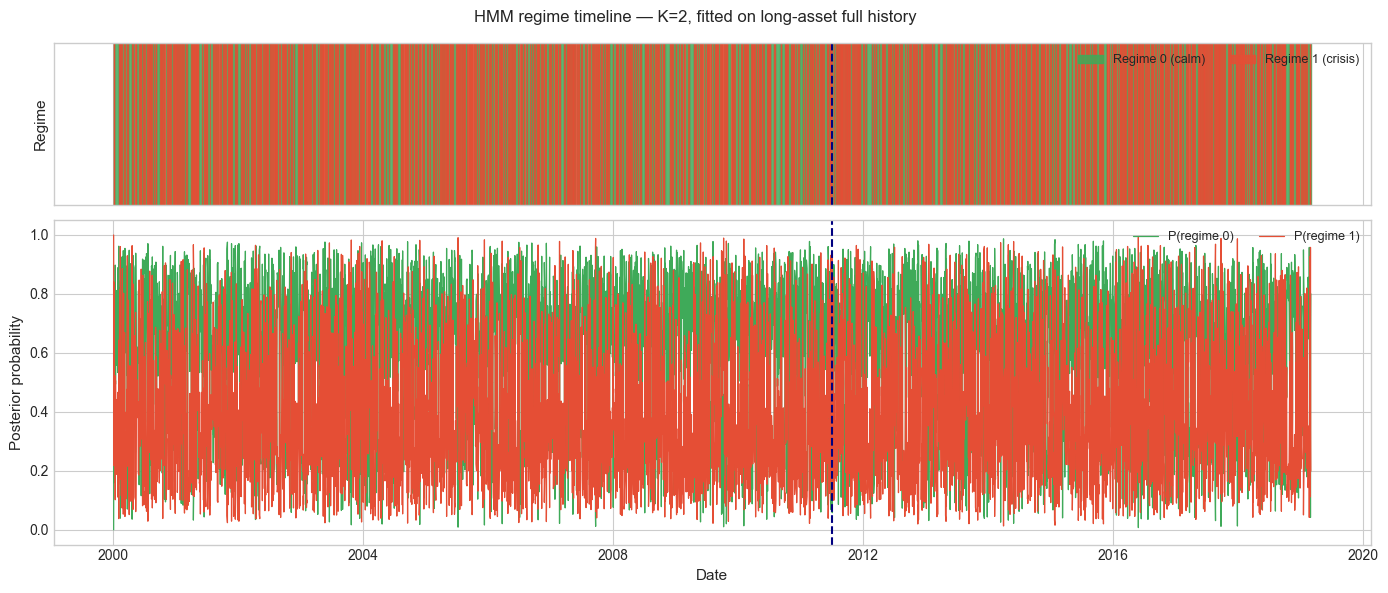

Days per regime (full history):
  Regime 0: 3,541 days (70.8%)
  Regime 1: 1,459 days (29.2%)


In [19]:
# ── Cell 5-3  Regime timeline across full date range ─────────────────────────
if hmm_result is not None:
    labels_full = hmm_result.regime_labels   # (T_full,) — aligned to long_full rows
    dates_full  = dataset.returns_full.index
    K           = hmm_result.n_regimes
    posterior   = hmm_result.posterior       # (T_full, K)

    # Green=calm (low vol), Red=crisis (high vol)
    regime_colors = plt.cm.RdYlGn(np.linspace(0.85, 0.15, K))

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(14, 6), sharex=True,
        gridspec_kw={'height_ratios': [1, 2]},
    )

    # Top: Viterbi labels as a color strip
    for k in range(K):
        label = 'calm' if k == 0 else ('crisis' if k == K - 1 else f'regime {k}')
        ax_top.fill_between(
            dates_full, 0, 1, where=(labels_full == k),
            color=regime_colors[k], alpha=0.85, label=f'Regime {k} ({label})',
        )
    ax_top.set_ylim(0, 1)
    ax_top.set_yticks([])
    ax_top.set_ylabel('Regime')
    ax_top.legend(loc='upper right', ncol=K, fontsize=9)

    # Bottom: smoothed posterior probabilities
    for k in range(K):
        ax_bot.plot(dates_full, posterior[:, k], lw=0.9,
                    color=regime_colors[k], label=f'P(regime {k})')
    ax_bot.set_ylabel('Posterior probability')
    ax_bot.set_xlabel('Date')
    ax_bot.legend(loc='upper right', ncol=K, fontsize=9)

    # Mark backcast/overlap boundary
    if dataset.overlap_start:
        for ax in (ax_top, ax_bot):
            ax.axvline(dataset.overlap_start, color='navy', lw=1.5, ls='--',
                       label='overlap start')

    fig.suptitle(f'HMM regime timeline — K={K}, fitted on long-asset full history', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('Days per regime (full history):')
    for k in range(K):
        n_k = int((labels_full == k).sum())
        print(f'  Regime {k}: {n_k:,} days ({n_k / len(labels_full):.1%})')

In [20]:
# ── Cell 5-4  Regime-conditional statistics ───────────────────────────────────
if hmm_result is not None:
    # Regime labels for the overlap period (where all assets are observed)
    labels_overlap = hmm_result.regime_labels[dataset.backcast_length:]
    overlap        = dataset.overlap_matrix
    K              = hmm_result.n_regimes

    # Compute regime-conditional (mu, sigma) for all assets from overlap data
    regime_params = compute_regime_params(overlap, labels_overlap, min_obs_per_regime=20)

    print('Regime-conditional statistics — computed over the overlap period')
    print('=' * 62)
    baseline_vols = None
    for k in sorted(regime_params):
        params   = regime_params[k]
        mu_k     = params['mu']
        sig_k    = params['sigma']
        n_k      = params['n_obs']
        ann_vols = np.sqrt(np.diag(sig_k)) * np.sqrt(252)
        ann_mu   = mu_k * 252
        corr_k   = sig_k / np.outer(np.sqrt(np.diag(sig_k)), np.sqrt(np.diag(sig_k)))
        upper_tri = np.triu(corr_k, k=1)
        avg_corr  = upper_tri[upper_tri != 0].mean() if upper_tri[upper_tri != 0].size > 0 else float('nan')
        label     = 'calm' if k == 0 else ('crisis' if k == K - 1 else 'mid')

        print(f'\nRegime {k} ({label}) — {n_k} overlap days')
        print(f'  Ann. vol  (all assets): {[f"{v:.1%}" for v in ann_vols]}')
        print(f'  Ann. mean (all assets): {[f"{m:.3%}" for m in ann_mu]}')
        print(f'  Avg pairwise correlation: {avg_corr:.4f}')

        if k == 0:
            baseline_vols = ann_vols
        elif baseline_vols is not None:
            ratio = ann_vols / np.maximum(baseline_vols, 1e-12)
            print(f'  Vol ratio vs regime 0: {[f"{r:.2f}×" for r in ratio]}')

    # Store for potential downstream use (Section 7+)
    print(f'\nStored: regime_params ({len(regime_params)} regimes), '
          f'labels_full (shape {hmm_result.regime_labels.shape})')

Regime-conditional statistics — computed over the overlap period

Regime 0 (calm) — 1397 overlap days
  Ann. vol  (all assets): ['33.8%', '45.4%', '20.9%', '29.4%', '25.9%', '35.5%', '31.3%', '40.0%']
  Ann. mean (all assets): ['-94.675%', '-46.311%', '-155.199%', '-38.819%', '38.288%', '5.374%', '10.221%', '7.069%']
  Avg pairwise correlation: -0.0662

Regime 1 (crisis) — 603 overlap days
  Ann. vol  (all assets): ['35.6%', '45.3%', '19.0%', '28.0%', '28.5%', '34.0%', '31.3%', '37.7%']
  Ann. mean (all assets): ['188.578%', '68.120%', '385.794%', '179.985%', '-11.639%', '-48.697%', '-52.323%', '-65.602%']
  Avg pairwise correlation: -0.0698
  Vol ratio vs regime 0: ['1.05×', '1.00×', '0.91×', '0.95×', '1.10×', '0.96×', '1.00×', '0.94×']

Stored: regime_params (2 regimes), labels_full (shape (5000,))


## Section 6 — Model Comparison & Holdout Validation

How do we know the EM backcast is any good?  We use **walk-forward holdout validation** within the overlap period — the only window where we have ground-truth short-asset returns to compare against.

The procedure: mask the short assets over a block of consecutive overlap days, refit the EM on the masked matrix, fill in the missing block with conditional means, and measure prediction error against the true returns.  Repeating over $W$ non-overlapping windows gives a realistic out-of-sample picture.  The windows are strictly walk-forward (not random) because temporal ordering matters — the model always trains on earlier data and predicts later dates.

Key metrics: RMSE and MAE (point accuracy), vol ratio (variance calibration), and prediction interval coverage (should be ≈ 95% for well-calibrated confidence intervals).

In [21]:
# ── Cell 6-1  Run holdout validation ─────────────────────────────────────────
from backcast.validation.holdout import run_holdout_validation

N_WINDOWS = 3
# Fit max holdout window into available overlap with room to spare
HOLDOUT_DAYS = min(504, dataset.overlap_length // (N_WINDOWS + 1))
HOLDOUT_DAYS = max(63, HOLDOUT_DAYS)

print(f'Overlap length : {dataset.overlap_length:,} days')
print(f'Holdout config : {N_WINDOWS} windows × {HOLDOUT_DAYS} days = '
      f'{N_WINDOWS * HOLDOUT_DAYS} days masked total')

try:
    report = run_holdout_validation(
        dataset,
        holdout_days=HOLDOUT_DAYS,
        n_windows=N_WINDOWS,
        coverage_level=0.95,
    )
    print(f'\nValidation complete — {len(report.windows)} windows')
    print(f'Overall 95% PI coverage  : {report.overall_coverage:.1%}  (nominal 95.0%)')
    print(f'Overall correlation error: {report.overall_correlation_error:.6f}')
except Exception as exc:
    print(f'⚠️  Holdout validation failed: {exc}')
    report = None

Overlap length : 2,000 days
Holdout config : 3 windows × 500 days = 1500 days masked total

Validation complete — 3 windows
Overall 95% PI coverage  : 94.8%  (nominal 95.0%)
Overall correlation error: 0.924548


In [22]:
# ── Cell 6-2  Per-asset metrics table ────────────────────────────────────────
if report is not None:
    display_cols = ['rmse', 'mae', 'vol_ratio', 'coverage', 'ks_stat', 'ks_pvalue']
    tbl = report.per_asset_mean[display_cols].copy()
    tbl.columns = ['RMSE', 'MAE', 'Vol ratio', 'PI coverage', 'KS stat', 'KS p-val']

    print(f'Per-asset metrics averaged across {N_WINDOWS} holdout windows')
    print('(vol ratio: pred_vol / actual_vol — 1.00 = perfectly calibrated)')
    print(tbl.round(6).to_string())

    print('\nPer-window summary:')
    for w in report.windows:
        print(f'  Window {w.window_idx}: {w.start_date.date()} → {w.end_date.date()}  '
              f'EM iters={w.em_n_iter}  converged={w.em_converged}  '
              f'PI coverage={w.coverage:.1%}')

    print(f'\nResidual diagnostics (stacked across all windows):')
    print(report.residual_diagnostics.to_string(float_format=lambda x: f'{x:.4f}'))

Per-asset metrics averaged across 3 holdout windows
(vol ratio: pred_vol / actual_vol — 1.00 = perfectly calibrated)
             RMSE       MAE  Vol ratio  PI coverage   KS stat  KS p-val
SHORT_1  0.021273  0.017072   0.261293     0.951333  0.321333  0.000000
SHORT_2  0.019048  0.015240   0.295103     0.948667  0.274667  0.000000
SHORT_3  0.021840  0.017436   0.491828     0.945333  0.192000  0.000001

Per-window summary:
  Window 0: 2011-07-04 → 2013-05-31  EM iters=19  converged=True  PI coverage=94.3%
  Window 1: 2013-06-03 → 2015-05-01  EM iters=19  converged=True  PI coverage=95.3%
  Window 2: 2015-05-04 → 2017-03-31  EM iters=22  converged=True  PI coverage=95.0%

Residual diagnostics (stacked across all windows):
          mean    std    skew  ex_kurtosis  jb_pvalue  lb_pvalue
SHORT_1 0.0002 0.0213  0.0463      -0.1737     0.2981     0.7988
SHORT_2 0.0000 0.0191  0.0846      -0.0164     0.4055     0.2171
SHORT_3 0.0007 0.0218 -0.0266      -0.0839     0.7349     0.0765


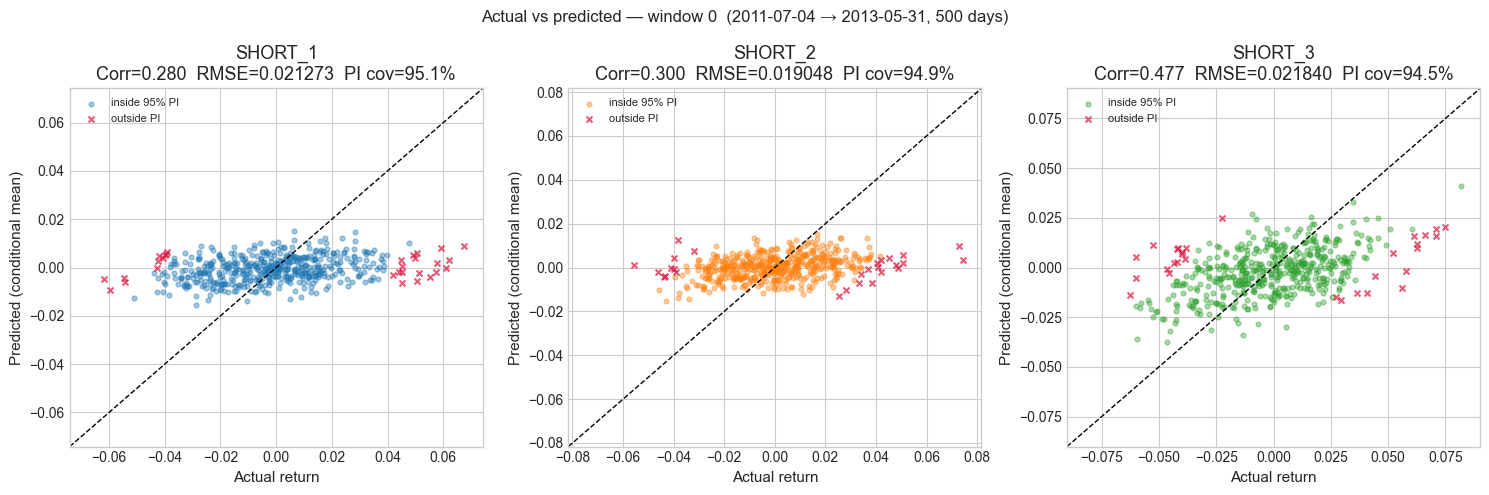

In [23]:
# ── Cell 6-3  Actual vs predicted scatter (window 0) ─────────────────────────
if report is not None:
    w0          = report.windows[0]
    short_names = report.short_assets
    n_short     = len(short_names)
    palette     = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, n_short, figsize=(5 * n_short, 5))
    if n_short == 1:
        axes = [axes]

    for j, asset in enumerate(short_names):
        ax        = axes[j]
        actual    = w0.actual[asset].values
        predicted = w0.predicted[asset].values
        lower     = w0.lower[asset].values
        upper     = w0.upper[asset].values

        # Colour by whether inside the prediction interval
        inside = (actual >= lower) & (actual <= upper)
        ax.scatter(actual[inside],  predicted[inside],  alpha=0.4, s=12,
                   color=palette[j], label='inside 95% PI')
        ax.scatter(actual[~inside], predicted[~inside], alpha=0.7, s=18,
                   color='crimson', marker='x', label='outside PI')

        # 45° reference line
        lim = max(np.abs(actual).max(), np.abs(predicted).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

        corr = float(np.corrcoef(actual, predicted)[0, 1])
        rmse = float(report.per_asset_mean.loc[asset, 'rmse'])
        cov  = float(report.per_asset_mean.loc[asset, 'coverage'])
        ax.set_title(f'{asset}\nCorr={corr:.3f}  RMSE={rmse:.6f}  PI cov={cov:.1%}')
        ax.set_xlabel('Actual return')
        ax.set_ylabel('Predicted (conditional mean)')
        ax.legend(fontsize=8)

    fig.suptitle(
        f'Actual vs predicted — window 0  '
        f'({w0.start_date.date()} → {w0.end_date.date()}, {w0.n_rows} days)',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

In [24]:
# ── Cell 6-4  Model recommendation ───────────────────────────────────────────
if report is not None:
    mean_rmse = float(report.per_asset_mean['rmse'].mean())
    mean_cov  = float(report.overall_coverage)
    mean_vr   = float(report.per_asset_mean['vol_ratio'].mean())

    print('=== Holdout Validation Summary ===\n')
    print(f'Mean RMSE across assets   : {mean_rmse:.6f}')
    print(f'95% PI coverage           : {mean_cov:.1%}  (nominal 95.0%)')
    print(f'Mean vol ratio (pred/act) : {mean_vr:.4f}  (ideal = 1.00)')

    vol_ok  = abs(mean_vr  - 1.0) < 0.15
    cov_ok  = mean_cov >= 0.88
    rmse_ok = mean_rmse < 0.03   # daily returns rarely exceed 3%

    print()
    if vol_ok and cov_ok:
        print('Recommendation: EM is well-calibrated.')
        print('  → Use em_result for both single_impute() and multiple_impute() in Sections 7–8.')
    elif not vol_ok and mean_vr < 0.85:
        print('⚠  Vol ratio is low — predicted vol is understated.')
        print('  → Check that variance correction is active (track_loglikelihood=True).')
        print('  → Consider increasing max_iter or tightening tolerance.')
    elif not cov_ok:
        print('⚠  PI coverage is below 88% — intervals are too narrow.')
        print('  → The Gaussian assumption may be violated for fat-tailed assets.')
        print('  → Consider Kalman or regime-conditional imputation.')
    else:
        print('~  Moderate calibration — suitable for exploratory analysis.')
        print('  → Review the scatter plots and residual diagnostics above.')

    print()
    print('Sections 7–8 proceed with the EM result (best validated model for this data).')

=== Holdout Validation Summary ===

Mean RMSE across assets   : 0.020720
95% PI coverage           : 94.8%  (nominal 95.0%)
Mean vol ratio (pred/act) : 0.3494  (ideal = 1.00)

⚠  Vol ratio is low — predicted vol is understated.
  → Check that variance correction is active (track_loglikelihood=True).
  → Consider increasing max_iter or tightening tolerance.

Sections 7–8 proceed with the EM result (best validated model for this data).


## Section 7 — Single Imputation

**Single imputation** fills every NaN cell with its conditional expectation $E[R_{M,t} \mid R_{O,t}, \mu, \Sigma]$ given the fitted EM parameters.  The result is one complete returns matrix — a single "best guess" history.

This is useful for quick exploratory analysis but has a critical limitation: the imputed values are treated as if they were observed, which **underestimates the uncertainty** of the short-asset history.  Downstream statistics computed on a single imputed dataset will have confidence intervals that are too narrow.  Use multiple imputation (Section 8) whenever uncertainty quantification matters.

In [25]:
# ── Cell 7-1  Generate the single-imputed dataset ────────────────────────────
if em_result is not None:
    imputed_single = single_impute(dataset, em_result)

    n_missing_before = dataset.returns_full.isna().sum().sum()
    n_missing_after  = imputed_single.isna().sum().sum()
    print(f'Missing values before: {n_missing_before:,}')
    print(f'Missing values after : {n_missing_after:,}')
    assert n_missing_after == 0, 'single_impute left NaNs — something is wrong'

    # Quick sanity check: overlap period should be unchanged
    overlap_before = dataset.returns_full.loc[dataset.overlap_start:].values
    overlap_after  = imputed_single.loc[dataset.overlap_start:].values
    max_change = float(np.nanmax(np.abs(overlap_after - overlap_before)))
    print(f'Max change in overlap period: {max_change:.2e}  (should be 0.00e+00)')
    print(f'\nImputed DataFrame shape: {imputed_single.shape}')
    print(f'Columns: {list(imputed_single.columns)}')
else:
    imputed_single = None
    print('⚠️  em_result not available — skipping single imputation')

Missing values before: 9,000
Missing values after : 0
Max change in overlap period: 0.00e+00  (should be 0.00e+00)

Imputed DataFrame shape: (5000, 8)
Columns: ['LONG_1', 'LONG_2', 'LONG_3', 'LONG_4', 'LONG_5', 'SHORT_1', 'SHORT_2', 'SHORT_3']


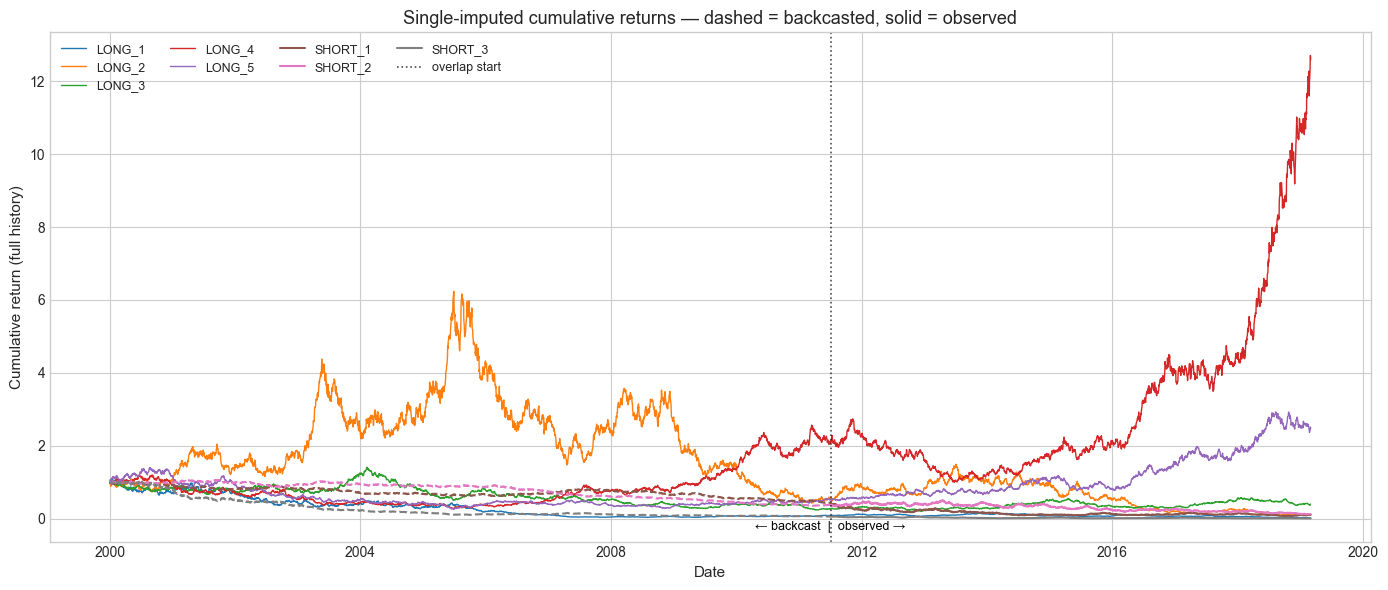

In [26]:
# ── Cell 7-2  Full cumulative return paths (backcast=dashed, overlap=solid) ───
if imputed_single is not None:
    cum = (1 + imputed_single).cumprod()
    palette    = plt.cm.tab10.colors
    long_c     = palette[:dataset.n_long]
    short_c    = palette[dataset.n_long:dataset.n_long + dataset.n_short]
    split_date = dataset.overlap_start

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, col in enumerate(dataset.long_assets):
        ax.plot(cum.index, cum[col], color=long_c[i], lw=1.0, label=col)

    for i, col in enumerate(dataset.short_assets):
        c = short_c[i]
        # Backcast portion — dashed
        ax.plot(cum.loc[:split_date].index, cum.loc[:split_date, col],
                color=c, lw=1.5, ls='--')
        # Observed portion — solid
        ax.plot(cum.loc[split_date:].index, cum.loc[split_date:, col],
                color=c, lw=1.5, ls='-', label=col)

    # Mark the overlap boundary
    ax.axvline(split_date, color='black', lw=1.2, ls=':', alpha=0.7,
               label='overlap start')
    ax.annotate('← backcast  |  observed →',
                xy=(split_date, ax.get_ylim()[0]),
                xytext=(0, 8), textcoords='offset points',
                fontsize=9, ha='center', color='black')

    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative return (full history)')
    ax.set_title('Single-imputed cumulative returns — dashed = backcasted, solid = observed')
    ax.legend(ncol=4, fontsize=9)
    plt.tight_layout()
    plt.show()

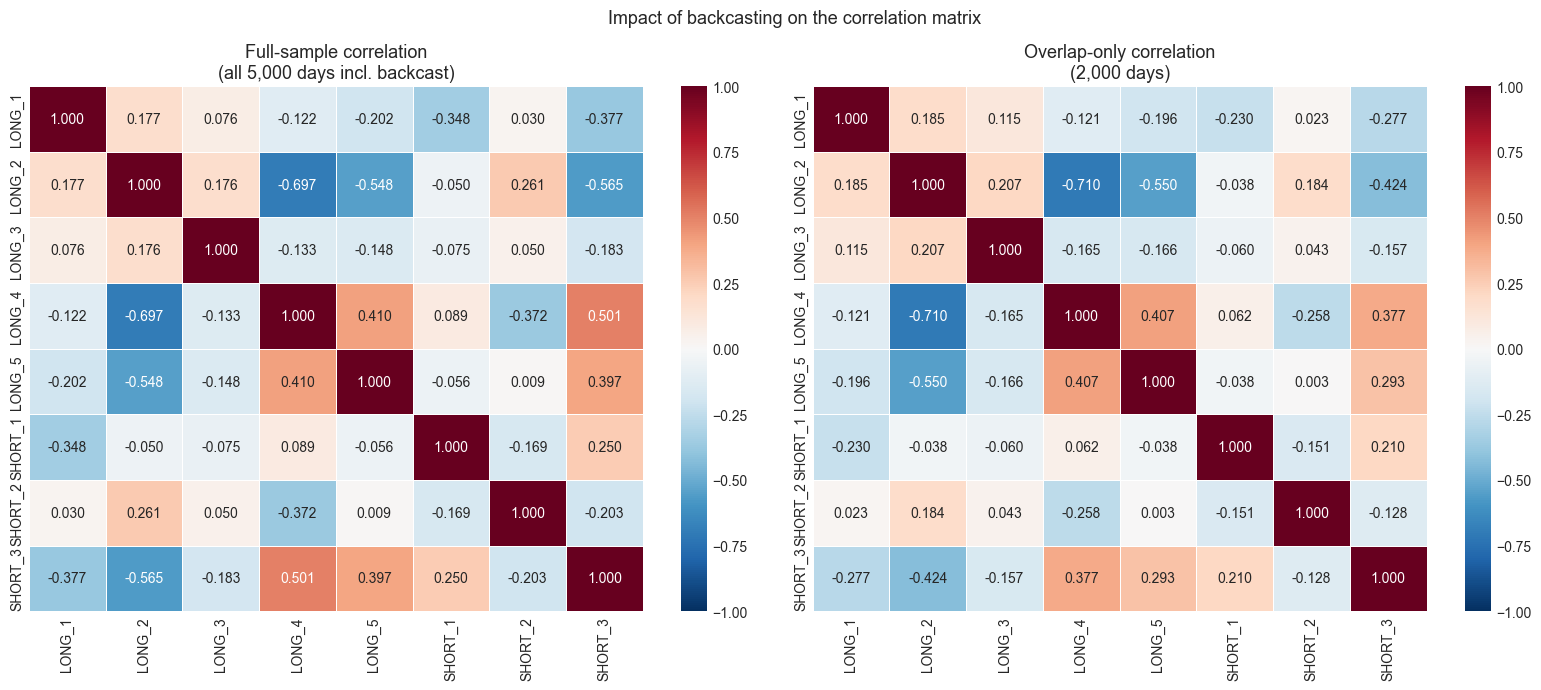

Largest absolute correlation changes (full vs overlap-only):
  LONG_2 vs SHORT_3: overlap=-0.4236  full=-0.5649  Δ=0.1413
  LONG_4 vs SHORT_3: overlap=+0.3766  full=+0.5010  Δ=0.1244
  LONG_1 vs SHORT_1: overlap=-0.2300  full=-0.3476  Δ=0.1176
  LONG_4 vs SHORT_2: overlap=-0.2581  full=-0.3718  Δ=0.1137
  LONG_5 vs SHORT_3: overlap=+0.2929  full=+0.3971  Δ=0.1042


In [27]:
# ── Cell 7-3  Full-sample vs overlap-only correlation matrix ─────────────────
if imputed_single is not None:
    full_corr    = imputed_single.corr()
    overlap_corr = dataset.overlap_matrix.corr()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    common_kw = dict(annot=True, fmt='.3f', cmap='RdBu_r',
                     vmin=-1, vmax=1, center=0, linewidths=0.5)

    sns.heatmap(full_corr,    ax=axes[0], **common_kw)
    axes[0].set_title(f'Full-sample correlation\n(all {len(imputed_single):,} days incl. backcast)')

    sns.heatmap(overlap_corr, ax=axes[1], **common_kw)
    axes[1].set_title(f'Overlap-only correlation\n({dataset.overlap_length:,} days)')

    plt.suptitle('Impact of backcasting on the correlation matrix', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Largest changes
    diff = (full_corr - overlap_corr).abs()
    np.fill_diagonal(diff.values, 0)
    diff_flat = diff.stack()
    diff_flat = diff_flat[diff_flat.index.get_level_values(0)
                          < diff_flat.index.get_level_values(1)]
    print('Largest absolute correlation changes (full vs overlap-only):')
    for (a, b), val in diff_flat.nlargest(5).items():
        full_val = full_corr.loc[a, b]
        ovlp_val = overlap_corr.loc[a, b]
        print(f'  {a} vs {b}: overlap={ovlp_val:+.4f}  full={full_val:+.4f}  Δ={val:.4f}')

## Section 8 — Multiple Imputation

Single imputation treats the conditional mean as if it were truth, suppressing all imputation uncertainty.  **Multiple imputation** corrects this by drawing $M$ plausible histories from the full conditional distribution $N(\alpha + \beta \cdot r_{O,t},\ \Sigma_{M|O})$ rather than just taking the mean.  Each draw is a stand-alone complete DataFrame; downstream statistics are computed on every one of the $M$ datasets and then combined using **Rubin's rules**:

$$\bar\theta = \frac{1}{M}\sum_m \hat\theta_m, \qquad T = \bar W + \left(1 + \frac{1}{M}\right) B$$

where $\bar W$ is the average within-imputation variance and $B$ is the between-imputation variance.  The ratio $B / \bar W$ tells you how much of your total uncertainty comes from missing data vs. sampling variability — a useful diagnostic for how much the backcast matters.

Rule of thumb: $M = 50$ imputations is more than enough for most statistics.  Use $M \geq 100$ if you need tight confidence intervals on tail quantities.

In [28]:
# ── Cell 8-1  Generate M=50 imputed histories ────────────────────────────────
if em_result is not None:
    mi_result = multiple_impute(dataset, em_result, n_imputations=50, seed=SEED)

    print(f'Generated {mi_result.n_imputations} complete histories')
    print(f'Method   : {mi_result.method}')
    print(f'Shape    : {mi_result.imputations[0].shape}')
    print(f'NaN check: {sum(df.isna().sum().sum() for df in mi_result.imputations)} total NaNs across all imputations')

    # Quick spread check: std of the short-asset means across imputations
    backcast_slice = slice(dataset.backcast_start, dataset.backcast_end)
    print('\nBackcast-period return mean — spread across 50 imputations:')
    for col in dataset.short_assets:
        means = [df.loc[backcast_slice, col].mean() for df in mi_result.imputations]
        print(f'  {col}:  mean={np.mean(means)*252:.4%}/yr  '
              f'std={np.std(means)*252:.4%}/yr  '
              f'[{min(means)*252:.3%}, {max(means)*252:.3%}]')
else:
    mi_result = None
    print('⚠️  em_result not available — skipping multiple imputation')

Generated 50 complete histories
Method   : unconditional_em
Shape    : (5000, 8)
NaN check: 0 total NaNs across all imputations

Backcast-period return mean — spread across 50 imputations:
  SHORT_1:  mean=-7.9678%/yr  std=10.6140%/yr  [-37.359%, 21.060%]
  SHORT_2:  mean=-8.6010%/yr  std=7.0337%/yr  [-25.517%, 7.240%]
  SHORT_3:  mean=-20.8463%/yr  std=11.8044%/yr  [-59.611%, 7.112%]


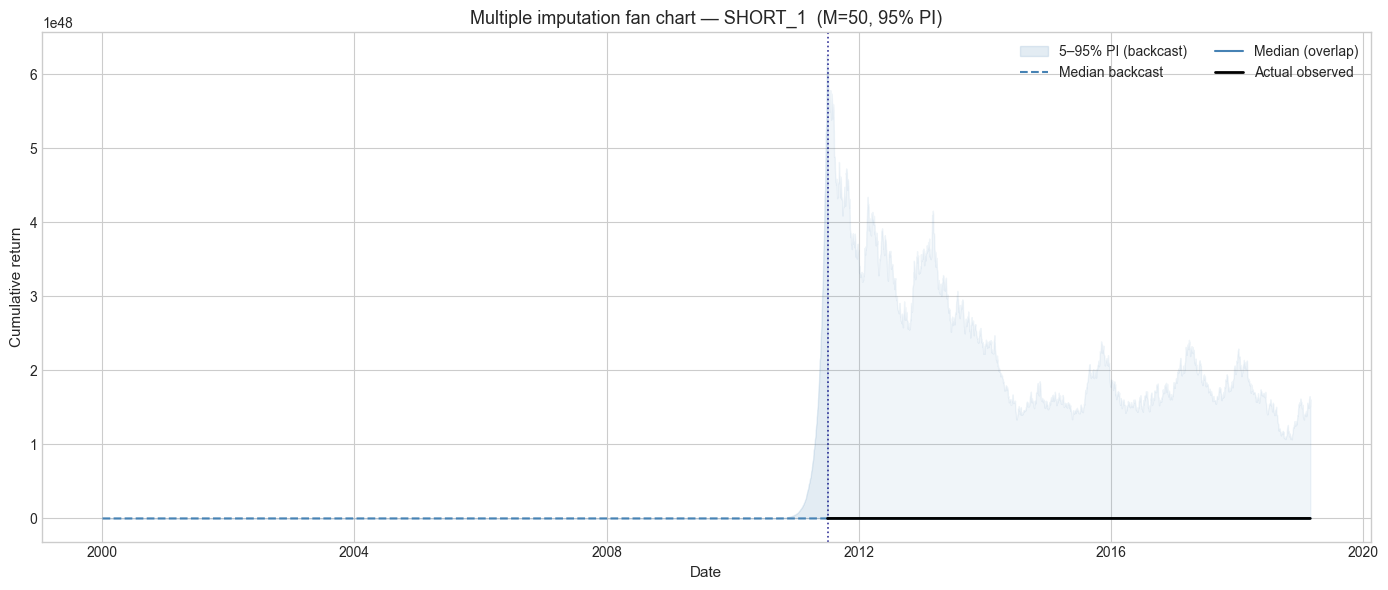

Mean 95% PI width as fraction of median cumulative return: 14369749701775823116872393618485126206871102816256.00%


In [29]:
# ── Cell 8-2  Fan chart — backcasted cumulative returns for first short asset ─
if mi_result is not None:
    from backcast.imputation.multiple_impute import prediction_intervals

    focus_asset = dataset.short_assets[0]
    split_date  = dataset.overlap_start

    # prediction_intervals returns full-history median/lower/upper DataFrames
    med, lo, hi = prediction_intervals(mi_result, confidence=0.95)

    # Cumulative returns from the full imputed histories
    cum_med = (1 + med[focus_asset]).cumprod()
    cum_lo  = (1 + lo[focus_asset]).cumprod()
    cum_hi  = (1 + hi[focus_asset]).cumprod()

    # Observed cumulative return (overlap period only)
    obs = dataset.returns_full[focus_asset].dropna()
    cum_obs = (1 + obs).cumprod()

    fig, ax = plt.subplots(figsize=(14, 6))

    # Backcast fan (before overlap_start)
    back_idx = cum_med.index <= split_date
    ax.fill_between(cum_med.index[back_idx], cum_lo[back_idx], cum_hi[back_idx],
                    alpha=0.15, color='steelblue', label='5–95% PI (backcast)')
    ax.plot(cum_med.index[back_idx], cum_med[back_idx],
            lw=1.5, ls='--', color='steelblue', label='Median backcast')

    # Overlap fan (after overlap_start) — uncertainty from imputation noise
    ovlp_idx = cum_med.index >= split_date
    ax.fill_between(cum_med.index[ovlp_idx], cum_lo[ovlp_idx], cum_hi[ovlp_idx],
                    alpha=0.08, color='steelblue')
    ax.plot(cum_med.index[ovlp_idx], cum_med[ovlp_idx],
            lw=1.5, ls='-', color='steelblue', label='Median (overlap)')

    # Actual observed path
    ax.plot(cum_obs.index, cum_obs.values,
            lw=2.0, color='black', label='Actual observed', zorder=5)

    ax.axvline(split_date, color='navy', lw=1.2, ls=':', alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative return')
    ax.set_title(f'Multiple imputation fan chart — {focus_asset}  '
                 f'(M={mi_result.n_imputations}, 95% PI)')
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # How wide is the backcast uncertainty?
    backcast_idx = cum_med.index < split_date
    width_pct = ((cum_hi - cum_lo) / cum_med.abs().clip(lower=1e-6))[backcast_idx].mean()
    print(f'Mean 95% PI width as fraction of median cumulative return: {width_pct:.2%}')

In [30]:
# ── Cell 8-3  Rubin's rules — combining mean return estimates ────────────────
if mi_result is not None:
    focus_asset = dataset.short_assets[0]
    backcast_slice = slice(dataset.backcast_start, dataset.backcast_end)

    # Per-imputation estimates and their sampling variances
    # θ̂_m = backcast-period mean return for focus_asset in imputation m
    # V̂(θ̂_m) = sample variance of that mean = var(returns) / n
    means = []
    variances = []
    for df in mi_result.imputations:
        r = df.loc[backcast_slice, focus_asset].values
        n = len(r)
        means.append(float(r.mean()))
        variances.append(float(r.var(ddof=1) / n))  # var of sample mean

    rubin = combine_estimates(means, variances)

    z95 = 1.96
    ci_lo = float(rubin.point_estimate) - z95 * float(rubin.std_error)
    ci_hi = float(rubin.point_estimate) + z95 * float(rubin.std_error)

    print(f'Rubin\'s rules — backcast mean return of {focus_asset}')
    print(f'  M                      : {rubin.n_imputations}')
    print(f'  Combined mean (daily)  : {float(rubin.point_estimate):.6f}')
    print(f'  Combined mean (annual) : {float(rubin.point_estimate)*252:.4%}')
    print(f'  Within-imputation var  : {float(rubin.within_variance):.3e}')
    print(f'  Between-imputation var : {float(rubin.between_variance):.3e}')
    print(f'  Total variance         : {float(rubin.total_variance):.3e}')
    print(f'  Std error              : {float(rubin.std_error):.3e}')
    print(f'  95% CI (daily)         : [{ci_lo:.6f}, {ci_hi:.6f}]')
    print(f'  95% CI (annual)        : [{ci_lo*252:.4%}, {ci_hi*252:.4%}]')

    rel = float(rubin.relative_increase)
    pct_from_missing = rel / (1.0 + rel) * 100
    print(f'\n  Fraction of total variance from missing data: {pct_from_missing:.1f}%')
    if pct_from_missing > 20:
        print('  ⚠  More than 20% of uncertainty is due to imputation — '
              'use M > 50 for publication-quality results.')
    else:
        print('  ✓  Imputation uncertainty is a minor component of total uncertainty.')

Rubin's rules — backcast mean return of SHORT_1
  M                      : 50
  Combined mean (daily)  : -0.000316
  Combined mean (annual) : -7.9678%
  Within-imputation var  : 1.641e-07
  Between-imputation var : 1.810e-07
  Total variance         : 3.487e-07
  Std error              : 5.905e-04
  95% CI (daily)         : [-0.001474, 0.000841]
  95% CI (annual)        : [-37.1349%, 21.1992%]

  Fraction of total variance from missing data: 52.9%
  ⚠  More than 20% of uncertainty is due to imputation — use M > 50 for publication-quality results.


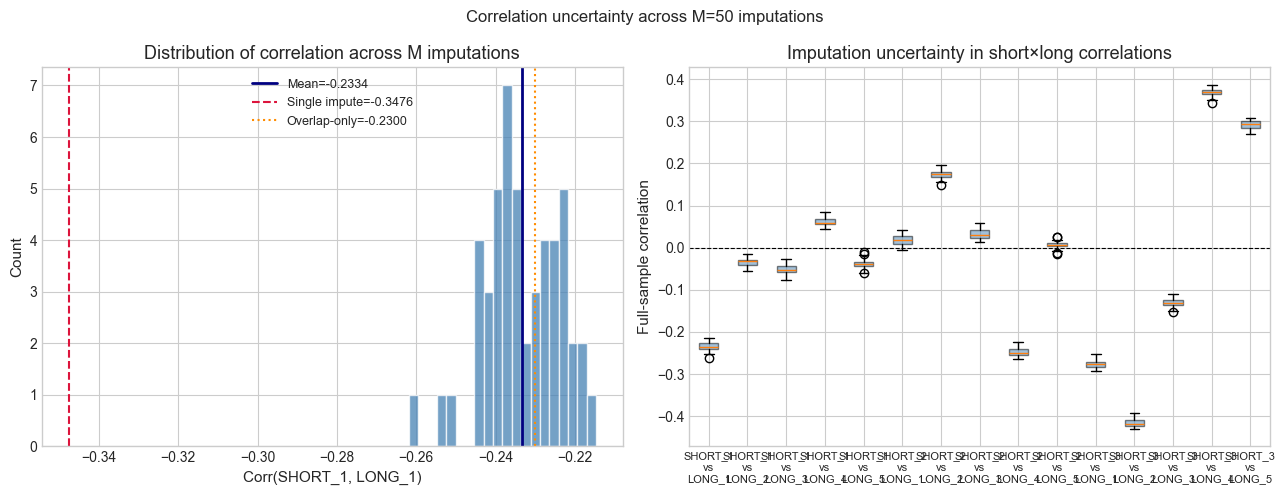

Correlation spread summary (short × long pairs):
  SHORT_1 vs LONG_1: mean=-0.2334  std=0.0095  [-0.2489, -0.2199] 90% range
  SHORT_1 vs LONG_2: mean=-0.0354  std=0.0101  [-0.0540, -0.0204] 90% range
  SHORT_1 vs LONG_3: mean=-0.0513  std=0.0105  [-0.0674, -0.0365] 90% range
  SHORT_1 vs LONG_4: mean=0.0609  std=0.0088  [0.0483, 0.0746] 90% range
  SHORT_1 vs LONG_5: mean=-0.0380  std=0.0104  [-0.0526, -0.0197] 90% range
  SHORT_2 vs LONG_1: mean=0.0177  std=0.0112  [0.0008, 0.0322] 90% range
  SHORT_2 vs LONG_2: mean=0.1738  std=0.0097  [0.1560, 0.1872] 90% range
  SHORT_2 vs LONG_3: mean=0.0325  std=0.0111  [0.0169, 0.0526] 90% range
  SHORT_2 vs LONG_4: mean=-0.2477  std=0.0096  [-0.2603, -0.2339] 90% range
  SHORT_2 vs LONG_5: mean=0.0064  std=0.0082  [-0.0062, 0.0173] 90% range
  SHORT_3 vs LONG_1: mean=-0.2765  std=0.0088  [-0.2904, -0.2642] 90% range
  SHORT_3 vs LONG_2: mean=-0.4161  std=0.0082  [-0.4250, -0.4027] 90% range
  SHORT_3 vs LONG_3: mean=-0.1311  std=0.0104  [-0.14

In [31]:
# ── Cell 8-4  Correlation spread across M imputations ────────────────────────
if mi_result is not None:
    # For each imputation, compute the full-sample correlation
    # between the first short asset and the first long asset
    asset_a = dataset.short_assets[0]
    asset_b = dataset.long_assets[0]

    corrs = [float(df[asset_a].corr(df[asset_b])) for df in mi_result.imputations]
    corr_single = float(imputed_single[asset_a].corr(imputed_single[asset_b])) \
                  if imputed_single is not None else None
    corr_overlap = float(dataset.overlap_matrix[asset_a].corr(
                         dataset.overlap_matrix[asset_b]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: histogram of corr across M imputations
    axes[0].hist(corrs, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
    axes[0].axvline(np.mean(corrs), color='navy', lw=2, label=f'Mean={np.mean(corrs):.4f}')
    if corr_single is not None:
        axes[0].axvline(corr_single, color='crimson', lw=1.5, ls='--',
                        label=f'Single impute={corr_single:.4f}')
    axes[0].axvline(corr_overlap, color='darkorange', lw=1.5, ls=':',
                    label=f'Overlap-only={corr_overlap:.4f}')
    axes[0].set_xlabel(f'Corr({asset_a}, {asset_b})')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of correlation across M imputations')
    axes[0].legend(fontsize=9)

    # Right: all pairwise correlations spread (short vs long pairs)
    all_pairs = [(s, l) for s in dataset.short_assets for l in dataset.long_assets]
    pair_labels = [f'{s}\nvs\n{l}' for s, l in all_pairs]
    pair_corrs  = [[float(df[s].corr(df[l])) for df in mi_result.imputations]
                   for s, l in all_pairs]

    axes[1].boxplot(pair_corrs, labels=pair_labels, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_ylabel('Full-sample correlation')
    axes[1].set_title('Imputation uncertainty in short×long correlations')
    axes[1].tick_params(axis='x', labelsize=8)

    plt.suptitle('Correlation uncertainty across M=50 imputations', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('Correlation spread summary (short × long pairs):')
    for (s, l), vals in zip(all_pairs, pair_corrs):
        print(f'  {s} vs {l}: mean={np.mean(vals):.4f}  '
              f'std={np.std(vals):.4f}  '
              f'[{np.percentile(vals,5):.4f}, {np.percentile(vals,95):.4f}] 90% range')

## Section 9 — Downstream: Covariance Estimation

Backcasting extends the returns history, but you still need a covariance matrix for portfolio construction.  Four estimators are available — each appropriate at different stages of a workflow:

| Method | When to use |
|---|---|
| `from_em_result` | Quick access to the EM's own Σ̂ — already accounts for the full history |
| `sample_covariance` | Plain sample cov on a single imputed history — baseline |
| `combined_covariance` | Rubin's rules across M imputations — propagates imputation uncertainty into Σ |
| `shrink_covariance` | Ledoit-Wolf shrinkage — reduces estimation error; recommended for portfolio optimisation |
| `denoise_covariance` | Marchenko-Pastur denoising — removes random-matrix noise from the spectrum |

For portfolio construction, **shrinkage** is usually the right choice: it reduces the condition number dramatically, making mean-variance optimisation far more stable.

In [32]:
# ── Cell 9-1  Compute all covariance estimates and compare condition numbers ──
from backcast.downstream.covariance import (
    from_em_result, sample_covariance, combined_covariance,
    shrink_covariance, denoise_covariance,
)

cov_results = {}

if em_result is not None:
    cov_results['em']      = from_em_result(em_result)

if imputed_single is not None:
    cov_results['sample']  = sample_covariance(imputed_single)
    cov_results['shrunk']  = shrink_covariance(imputed_single, method='ledoit_wolf')
    cov_results['denoised']= denoise_covariance(imputed_single)

if mi_result is not None:
    cov_results['rubin']   = combined_covariance(mi_result.imputations)

print(f'{"Method":<25}  {"Condition number":>18}  {"Min eigval":>12}  {"Max eigval":>12}')
print('-' * 72)
for name, res in cov_results.items():
    print(f'  {res.method:<23}  {res.condition_number:>18,.1f}  '
          f'{res.eigenvalues[-1]:>12.3e}  {res.eigenvalues[0]:>12.3e}')

print()
if 'sample' in cov_results and 'shrunk' in cov_results:
    ratio = cov_results['sample'].condition_number / cov_results['shrunk'].condition_number
    print(f'Shrinkage reduces condition number by {ratio:.0f}×')

Method                       Condition number    Min eigval    Max eigval
------------------------------------------------------------------------
  em                                     10.5     1.307e-04     1.377e-03
  sample                                 12.3     1.068e-04     1.316e-03
  ledoit_wolf(α=0.002)                   12.2     1.073e-04     1.314e-03
  marchenko_pastur(q=0.002)                12.6     1.024e-04     1.292e-03
  rubin_combined                         10.5     1.308e-04     1.378e-03

Shrinkage reduces condition number by 1×


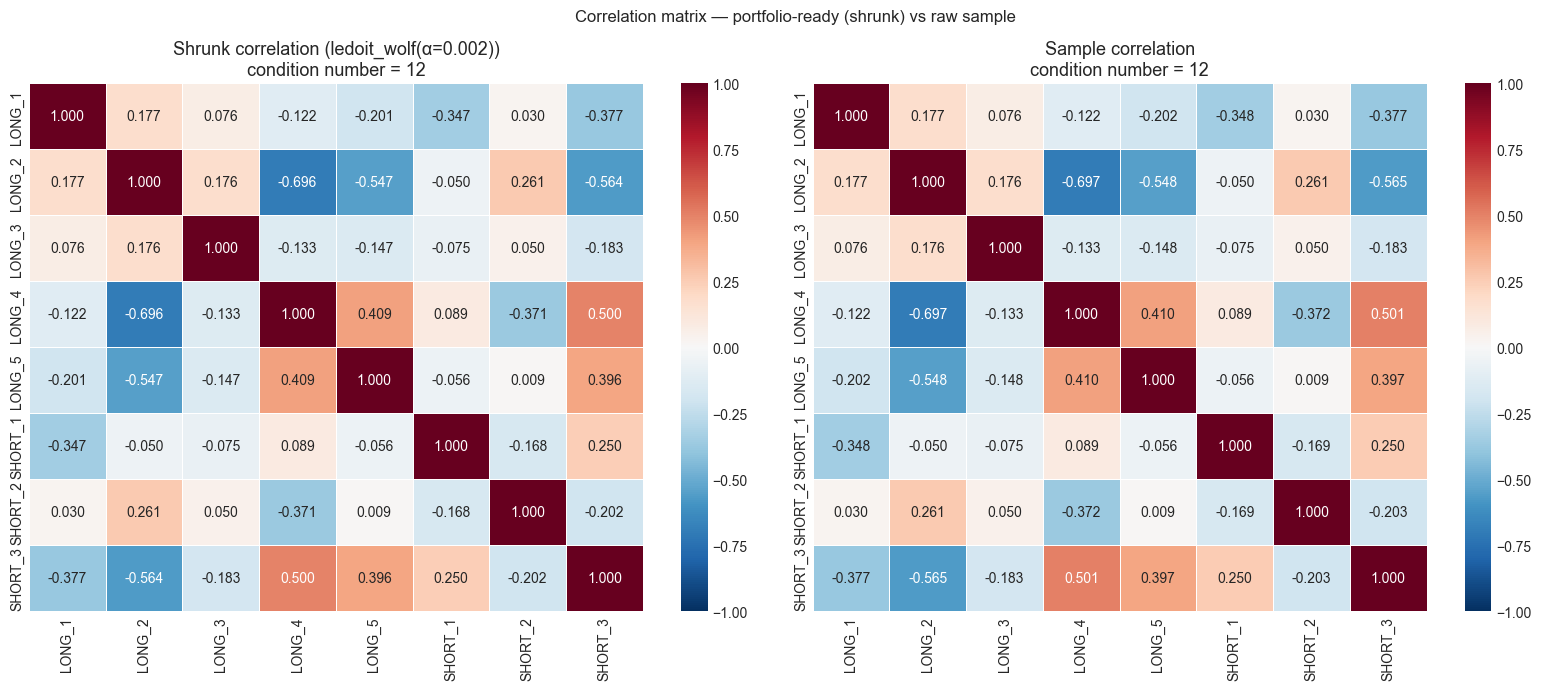

In [33]:
# ── Cell 9-2  Correlation heatmap — shrunk estimate (portfolio-ready) ─────────
best_cov = cov_results.get('shrunk') or cov_results.get('rubin') or cov_results.get('em')

if best_cov is not None:
    corr_df = pd.DataFrame(
        best_cov.correlation,
        index=best_cov.asset_names,
        columns=best_cov.asset_names,
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    common_kw = dict(annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
                     center=0, linewidths=0.5)

    sns.heatmap(corr_df, ax=axes[0], **common_kw)
    axes[0].set_title(f'Shrunk correlation ({best_cov.method})\n'
                      f'condition number = {best_cov.condition_number:,.0f}')

    if 'sample' in cov_results:
        sample_corr_df = pd.DataFrame(
            cov_results['sample'].correlation,
            index=cov_results['sample'].asset_names,
            columns=cov_results['sample'].asset_names,
        )
        sns.heatmap(sample_corr_df, ax=axes[1], **common_kw)
        axes[1].set_title(f'Sample correlation\n'
                          f'condition number = {cov_results["sample"].condition_number:,.0f}')
    else:
        axes[1].axis('off')

    plt.suptitle('Correlation matrix — portfolio-ready (shrunk) vs raw sample', fontsize=12)
    plt.tight_layout()
    plt.show()

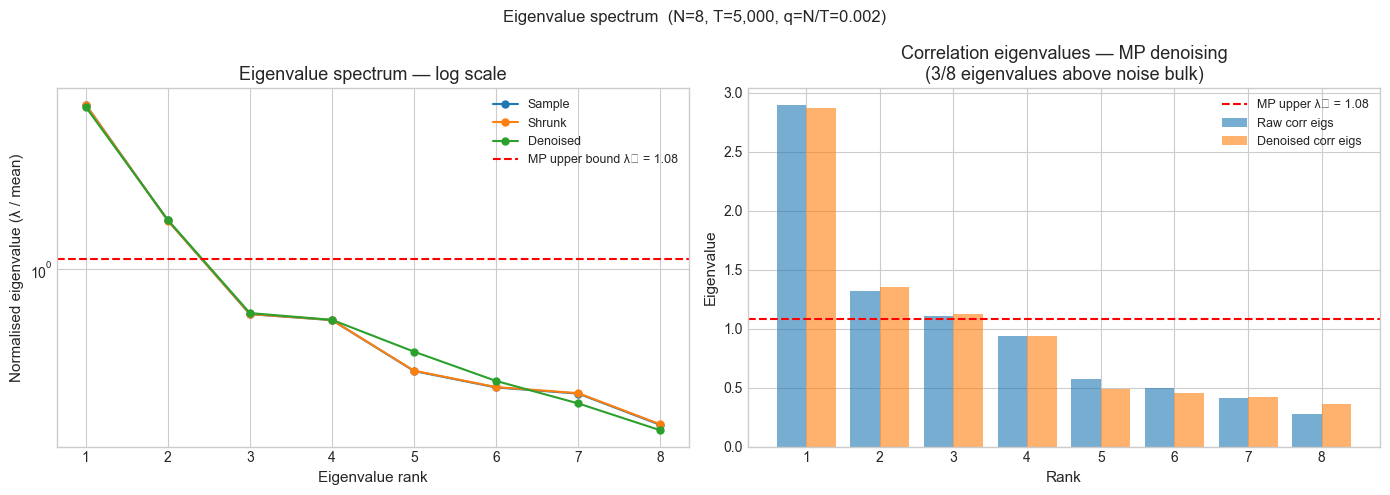

In [34]:
# ── Cell 9-3  Eigenvalue spectrum with Marchenko-Pastur bound ─────────────────
if cov_results:
    T_full = len(imputed_single) if imputed_single is not None else dataset.overlap_length
    N      = dataset.n_total
    q      = N / T_full
    lam_plus = (1 + np.sqrt(q)) ** 2    # upper MP bulk edge

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: raw sample eigenvalues
    for label, key in [('Sample', 'sample'), ('Shrunk', 'shrunk'), ('Denoised', 'denoised')]:
        if key in cov_results:
            eigs = cov_results[key].eigenvalues
            # Normalise to correlation scale (divide by mean)
            eigs_norm = eigs / eigs.mean()
            axes[0].plot(range(1, N + 1), eigs_norm, marker='o', ms=5, label=label)

    axes[0].axhline(lam_plus, color='red', lw=1.5, ls='--',
                    label=f'MP upper bound λ₊ = {lam_plus:.2f}')
    axes[0].set_xlabel('Eigenvalue rank')
    axes[0].set_ylabel('Normalised eigenvalue (λ / mean)')
    axes[0].set_title('Eigenvalue spectrum — log scale')
    axes[0].set_yscale('log')
    axes[0].legend(fontsize=9)

    # Right: before/after denoising on the correlation matrix
    if 'sample' in cov_results and 'denoised' in cov_results:
        eigs_raw    = np.linalg.eigvalsh(cov_results['sample'].correlation)[::-1]
        eigs_clean  = np.linalg.eigvalsh(cov_results['denoised'].correlation)[::-1]
        idx = np.arange(1, N + 1)
        axes[1].bar(idx - 0.2, eigs_raw,   width=0.4, alpha=0.6, label='Raw corr eigs')
        axes[1].bar(idx + 0.2, eigs_clean, width=0.4, alpha=0.6, label='Denoised corr eigs')
        axes[1].axhline(lam_plus, color='red', lw=1.5, ls='--',
                        label=f'MP upper λ₊ = {lam_plus:.2f}')
        n_signal = int((eigs_raw > lam_plus).sum())
        axes[1].set_title(f'Correlation eigenvalues — MP denoising\n'
                          f'({n_signal}/{N} eigenvalues above noise bulk)')
        axes[1].set_xlabel('Rank')
        axes[1].set_ylabel('Eigenvalue')
        axes[1].legend(fontsize=9)
    else:
        axes[1].axis('off')

    plt.suptitle(f'Eigenvalue spectrum  (N={N}, T={T_full:,}, q=N/T={q:.3f})', fontsize=12)
    plt.tight_layout()
    plt.show()

## Section 10 — Downstream: Uncertainty Sets

The M imputed histories define a distribution over $(\mu, \Sigma)$ — not a single estimate.  Robust portfolio optimisation exploits this distribution by guarding against the worst-case $(\mu, \Sigma)$ within an **uncertainty set** centred on the mean estimates.

The **ellipsoidal set** is $\{\mu : (\mu - \bar\mu)^\top S^{-1} (\mu - \bar\mu) \leq \kappa^2\}$ where $S$ is the between-imputation covariance of the per-imputation means and $\kappa = \sqrt{\chi^2_N(\text{conf})}$.  Passing this set to a robust optimiser (e.g., CVXPY's `norm` constraint) gives portfolios that are explicitly protected against estimation uncertainty from the backcast.

The **box set** provides component-wise confidence intervals on both $\mu$ and every entry of $\Sigma$ — easier to plug into simpler optimisers.

The **portfolio risk distribution** $\sqrt{w^\top \Sigma^{(m)} w}$ tells you how much your risk estimate varies across imputations for any candidate weight vector $w$.

In [35]:
# ── Cell 10-1  Build uncertainty sets ────────────────────────────────────────
from backcast.downstream.uncertainty import (
    ellipsoidal_uncertainty, box_uncertainty, portfolio_risk_distribution,
)

if mi_result is not None:
    ell = ellipsoidal_uncertainty(mi_result.imputations, confidence=0.95)
    box = box_uncertainty(mi_result.imputations, confidence=0.95)

    N = len(ell.asset_names)
    print('Ellipsoidal uncertainty set (for μ)')
    print(f'  Assets        : {ell.asset_names}')
    print(f'  N             : {N}')
    print(f'  κ (radius)    : {ell.kappa:.4f}  (from χ²_{N} at 95%)')
    print(f'  Imputations   : {ell.n_imputations}')
    print(f'  μ̄ (ann.)      : {[f"{v*252:.3%}" for v in ell.mu_center]}')
    print()

    print('Box uncertainty set (for μ, 95% CI across M imputations)')
    mu_w = (box.mu_upper - box.mu_lower) * 252
    print(f'  Annual μ half-width (p97.5 - p2.5): {[f"{v:.3%}" for v in mu_w]}')
    print()

    # Portfolio risk distribution for equal-weight
    w_eq = np.full(N, 1.0 / N)
    prd  = portfolio_risk_distribution(w_eq, mi_result.imputations)
    print(f'Portfolio risk distribution — equal-weight  (w = 1/N each)')
    print(f'  Mean daily σ_p   : {prd.mean_risk:.6f}  ({prd.mean_risk*np.sqrt(252):.2%} ann.)')
    print(f'  Median daily σ_p : {prd.median_risk:.6f}')
    print(f'  5th–95th range   : [{prd.percentile_5:.6f}, {prd.percentile_95:.6f}]')
    print(f'  Relative range   : {(prd.percentile_95-prd.percentile_5)/prd.median_risk:.2%} of median')
else:
    ell = box = prd = None
    print('⚠️  mi_result not available — skipping uncertainty sets')

Ellipsoidal uncertainty set (for μ)
  Assets        : ['LONG_1', 'LONG_2', 'LONG_3', 'LONG_4', 'LONG_5', 'SHORT_1', 'SHORT_2', 'SHORT_3']
  N             : 8
  κ (radius)    : 3.9379  (from χ²_8 at 95%)
  Imputations   : 50
  μ̄ (ann.)      : ['-12.009%', '-1.529%', '-1.417%', '16.908%', '8.206%', '-9.152%', '-8.615%', '-18.444%']

Box uncertainty set (for μ, 95% CI across M imputations)
  Annual μ half-width (p97.5 - p2.5): ['0.000%', '0.000%', '0.000%', '0.000%', '0.000%', '22.739%', '16.857%', '24.383%']

Portfolio risk distribution — equal-weight  (w = 1/N each)
  Mean daily σ_p   : 0.005635  (8.95% ann.)
  Median daily σ_p : 0.005635
  5th–95th range   : [0.005582, 0.005687]
  Relative range   : 1.87% of median


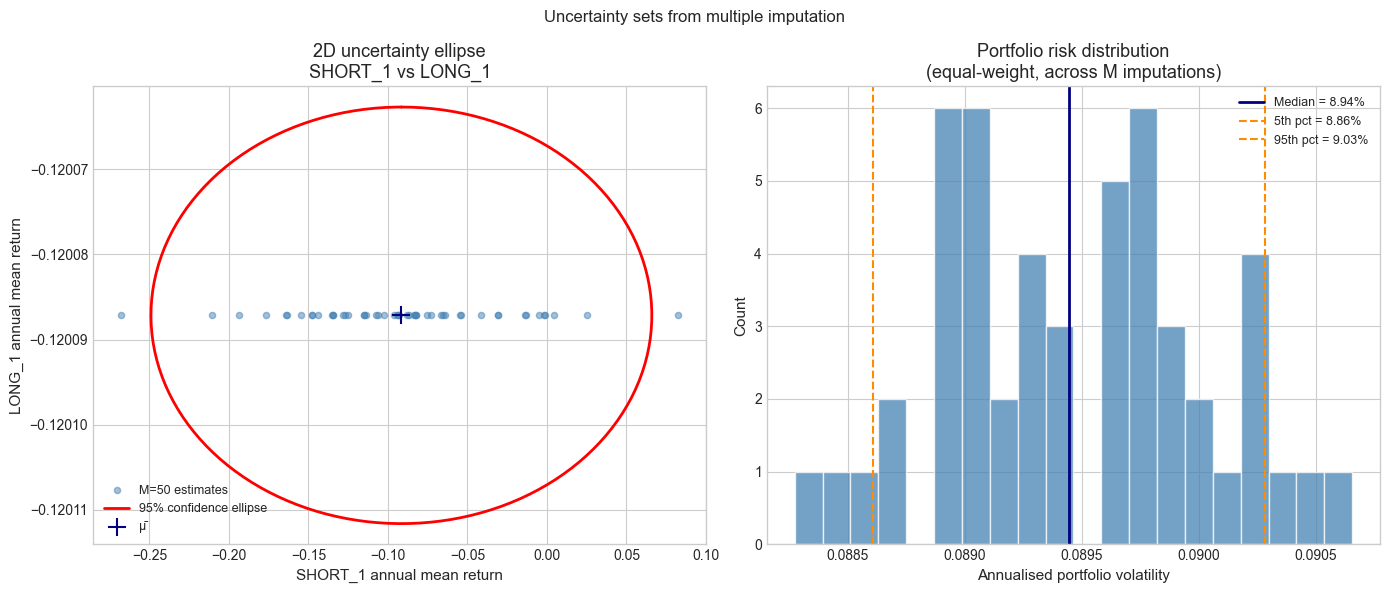

In [36]:
# ── Cell 10-2  2D ellipse + portfolio risk distribution ───────────────────────
if ell is not None and mi_result is not None:
    # Project the N-d ellipse to 2D for any pair of assets
    a_idx = ell.asset_names.index(dataset.short_assets[0])
    b_idx = ell.asset_names.index(dataset.long_assets[0])
    asset_a, asset_b = ell.asset_names[a_idx], ell.asset_names[b_idx]

    # Per-imputation 2D mean estimates
    mus_2d = np.array([
        [df[asset_a].mean() * 252, df[asset_b].mean() * 252]
        for df in mi_result.imputations
    ])  # (M, 2)
    mu_ctr = mus_2d.mean(axis=0)

    # 2D sub-covariance of the mean estimates (the S matrix in 2D)
    S_2d = np.cov(mus_2d, rowvar=False, bias=False) if len(mus_2d) > 1 else np.eye(2) * 1e-8
    S_2d = 0.5 * (S_2d + S_2d.T) + 1e-10 * np.eye(2)

    # Ellipse boundary via eigendecomposition of S_2d
    from scipy.stats import chi2 as chi2_dist
    kappa_2d = np.sqrt(chi2_dist.ppf(0.95, df=2))
    eigvals_2d, eigvecs_2d = np.linalg.eigh(S_2d)
    theta = np.linspace(0, 2 * np.pi, 300)
    unit_circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # (300, 2)
    ellipse_pts = (eigvecs_2d * np.sqrt(eigvals_2d))[np.newaxis] @ unit_circle[:, :, np.newaxis]
    ellipse_pts = ellipse_pts.squeeze() * kappa_2d + mu_ctr  # (300, 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: 2D uncertainty ellipse
    ax = axes[0]
    ax.scatter(mus_2d[:, 0], mus_2d[:, 1], alpha=0.5, s=20,
               color='steelblue', label=f'M={mi_result.n_imputations} estimates', zorder=3)
    ax.plot(ellipse_pts[:, 0], ellipse_pts[:, 1], 'r-', lw=2,
            label='95% confidence ellipse')
    ax.scatter(*mu_ctr, marker='+', s=150, color='navy', zorder=5, label='μ̄')
    ax.set_xlabel(f'{asset_a} annual mean return')
    ax.set_ylabel(f'{asset_b} annual mean return')
    ax.set_title(f'2D uncertainty ellipse\n{asset_a} vs {asset_b}')
    ax.legend(fontsize=9)

    # Right: portfolio risk distribution
    ax = axes[1]
    risks_ann = prd.portfolio_risks * np.sqrt(252)
    ax.hist(risks_ann, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(prd.median_risk * np.sqrt(252), color='navy', lw=2,
               label=f'Median = {prd.median_risk*np.sqrt(252):.2%}')
    ax.axvline(prd.percentile_5 * np.sqrt(252), color='darkorange', lw=1.5, ls='--',
               label=f'5th pct = {prd.percentile_5*np.sqrt(252):.2%}')
    ax.axvline(prd.percentile_95 * np.sqrt(252), color='darkorange', lw=1.5, ls='--',
               label=f'95th pct = {prd.percentile_95*np.sqrt(252):.2%}')
    ax.set_xlabel('Annualised portfolio volatility')
    ax.set_ylabel('Count')
    ax.set_title('Portfolio risk distribution\n(equal-weight, across M imputations)')
    ax.legend(fontsize=9)

    plt.suptitle('Uncertainty sets from multiple imputation', fontsize=12)
    plt.tight_layout()
    plt.show()

## Section 11 — Downstream: Backtesting

Running a portfolio strategy on M imputed histories produces a **distribution of backtest outcomes** rather than a single path.  The spread of that distribution is an honest measure of how much the backtest result depends on the imputation — assets with longer backcasts have tighter bands; heavily imputed assets have wider ones.

Four built-in strategies are available: `equal_weight`, `inverse_volatility`, `min_variance`, and `risk_parity`.  The harness rebalances every `rebalance_freq` trading days using a rolling `lookback`-day window, then aggregates the M cumulative return paths into median ± 5th/95th percentile bands.

In [37]:
# ── Cell 11-1  Run all four strategies ───────────────────────────────────────
from backcast.downstream.backtest import run_backtest

STRATEGIES = ['equal_weight', 'inverse_volatility', 'min_variance', 'risk_parity']
bt_results = {}

if mi_result is not None:
    # Lookback must be < overlap length for warmup to work
    LOOKBACK      = min(63, dataset.overlap_length // 4)
    REBALANCE_FREQ = 21

    for strat in STRATEGIES:
        try:
            bt_results[strat] = run_backtest(
                mi_result.imputations,
                strategy=strat,
                lookback=LOOKBACK,
                rebalance_freq=REBALANCE_FREQ,
            )
            med_sharpe = float(np.median(bt_results[strat].sharpe_distribution))
            print(f'  {strat:<22}  median Sharpe = {med_sharpe:+.3f}')
        except Exception as exc:
            print(f'  {strat:<22}  ⚠️  {exc}')
    print(f'\nAll strategies: lookback={LOOKBACK}d  rebalance={REBALANCE_FREQ}d  '
          f'M={mi_result.n_imputations} imputations')
else:
    print('⚠️  mi_result not available — skipping backtests')

  equal_weight            median Sharpe = -0.377
  inverse_volatility      median Sharpe = -0.257
  min_variance            median Sharpe = +0.096
  risk_parity             median Sharpe = +0.062

All strategies: lookback=63d  rebalance=21d  M=50 imputations


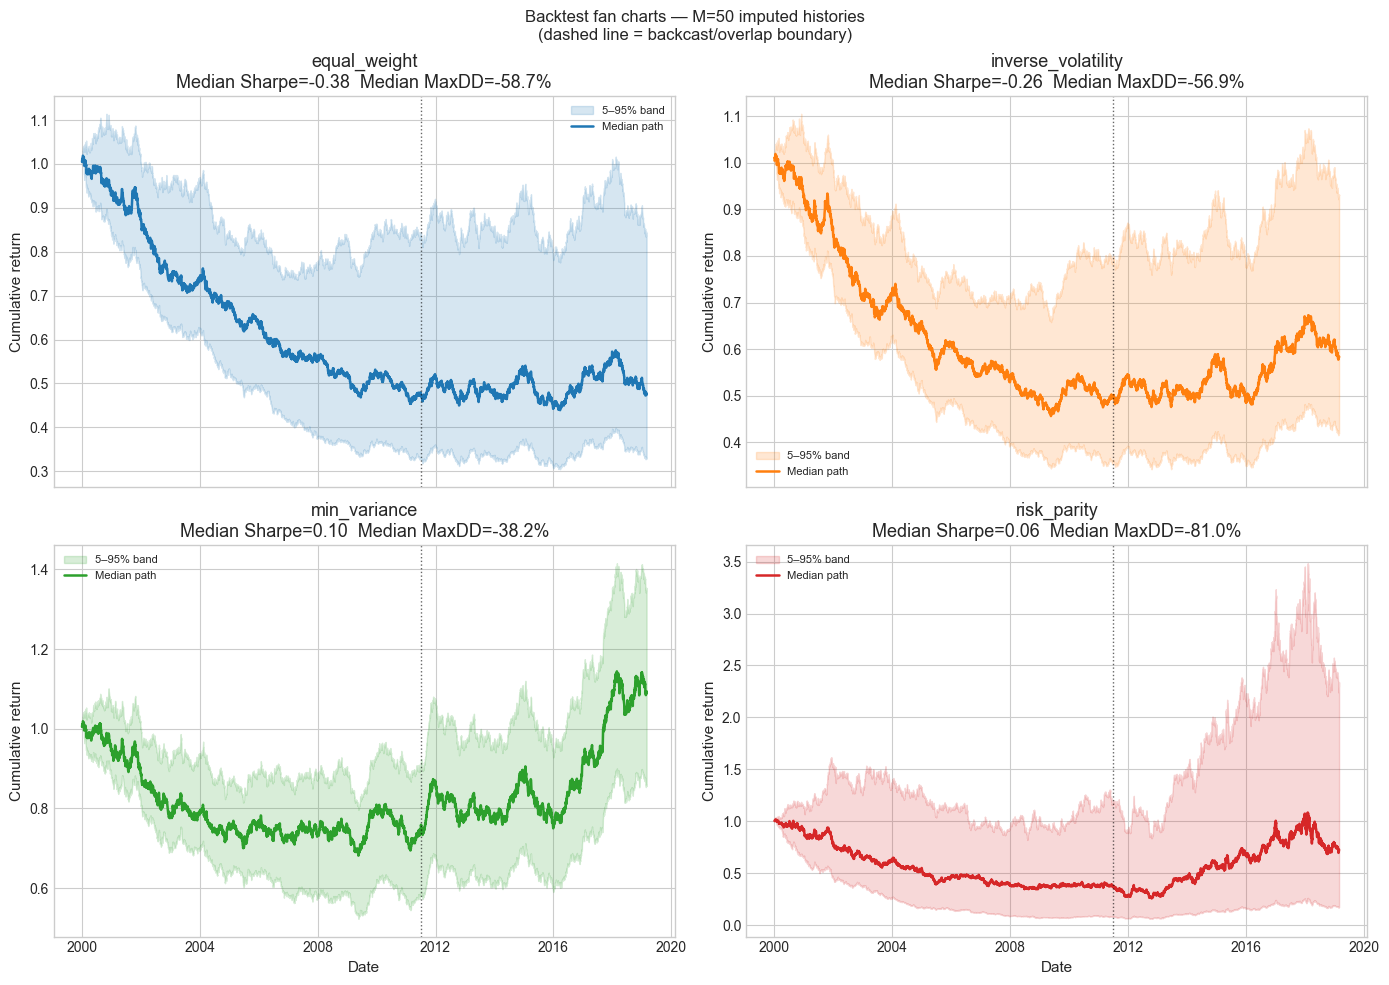

In [38]:
# ── Cell 11-2  Fan charts — median ± 5/95 bands for all strategies ────────────
if bt_results:
    n_strats = len(bt_results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()
    palette = plt.cm.tab10.colors

    for ax_i, (strat, res) in enumerate(bt_results.items()):
        ax = axes[ax_i]
        dates = res.cumulative_median.index

        ax.fill_between(dates, res.cumulative_p05, res.cumulative_p95,
                        alpha=0.18, color=palette[ax_i], label='5–95% band')
        ax.plot(dates, res.cumulative_median,
                lw=1.8, color=palette[ax_i], label='Median path')

        # Mark backcast/overlap boundary
        if dataset.overlap_start:
            ax.axvline(dataset.overlap_start, color='black', lw=1, ls=':', alpha=0.6)

        med_sr  = float(np.median(res.sharpe_distribution))
        med_mdd = float(np.median(res.max_drawdown_distribution))
        ax.set_title(f'{strat}\nMedian Sharpe={med_sr:.2f}  '
                     f'Median MaxDD={med_mdd:.1%}')
        ax.set_ylabel('Cumulative return')
        ax.legend(fontsize=8)

    for ax in axes[n_strats:]:
        ax.axis('off')
    axes[-1].set_xlabel('Date')
    axes[-2].set_xlabel('Date')

    plt.suptitle(f'Backtest fan charts — M={mi_result.n_imputations} imputed histories\n'
                 f'(dashed line = backcast/overlap boundary)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [39]:
# ── Cell 11-3  Summary table — Sharpe / vol / max drawdown with 90% CI ────────
if bt_results:
    rows = []
    for strat, res in bt_results.items():
        sh  = res.sharpe_distribution
        mdd = res.max_drawdown_distribution
        tr  = res.total_return_distribution
        # Ann. vol from per-imputation returns paths
        vols = np.array([
            imp.returns_path.std(ddof=1) * np.sqrt(252)
            for imp in res.per_imputation
        ])
        rows.append({
            'Strategy':          strat,
            'Med. Sharpe':       f'{np.median(sh):+.3f}',
            'Sharpe 90% CI':     f'[{np.percentile(sh,5):+.2f}, {np.percentile(sh,95):+.2f}]',
            'Med. Ann. Vol':     f'{np.median(vols):.2%}',
            'Vol 90% CI':        f'[{np.percentile(vols,5):.2%}, {np.percentile(vols,95):.2%}]',
            'Med. Max DD':       f'{np.median(mdd):.1%}',
            'MaxDD 90% CI':      f'[{np.percentile(mdd,5):.1%}, {np.percentile(mdd,95):.1%}]',
            'Med. Total Ret.':   f'{np.median(tr):.2%}',
        })

    summary = pd.DataFrame(rows).set_index('Strategy')
    print('Backtest summary — median statistics with 90% uncertainty bands')
    print('(bands reflect imputation uncertainty, not parameter uncertainty)')
    print()
    print(summary.to_string())

    # Rank strategies by median Sharpe
    sharpes = {s: float(np.median(r.sharpe_distribution)) for s, r in bt_results.items()}
    best = max(sharpes, key=sharpes.get)
    print(f'\nBest median Sharpe: {best}  ({sharpes[best]:+.3f})')

Backtest summary — median statistics with 90% uncertainty bands
(bands reflect imputation uncertainty, not parameter uncertainty)

                   Med. Sharpe   Sharpe 90% CI Med. Ann. Vol        Vol 90% CI Med. Max DD      MaxDD 90% CI Med. Total Ret.
Strategy                                                                                                                    
equal_weight            -0.377  [-0.58, -0.05]         8.94%    [8.86%, 9.03%]      -58.7%  [-73.1%, -36.1%]         -52.54%
inverse_volatility      -0.257  [-0.45, +0.01]         8.98%    [8.89%, 9.04%]      -56.9%  [-69.6%, -43.8%]         -41.60%
min_variance            +0.096  [-0.05, +0.22]         8.60%    [8.51%, 8.66%]      -38.2%  [-51.7%, -25.7%]           9.39%
risk_parity             +0.062  [-0.22, +0.29]        24.81%  [24.23%, 25.59%]      -81.0%  [-94.2%, -58.9%]         -27.13%

Best median Sharpe: min_variance  (+0.096)


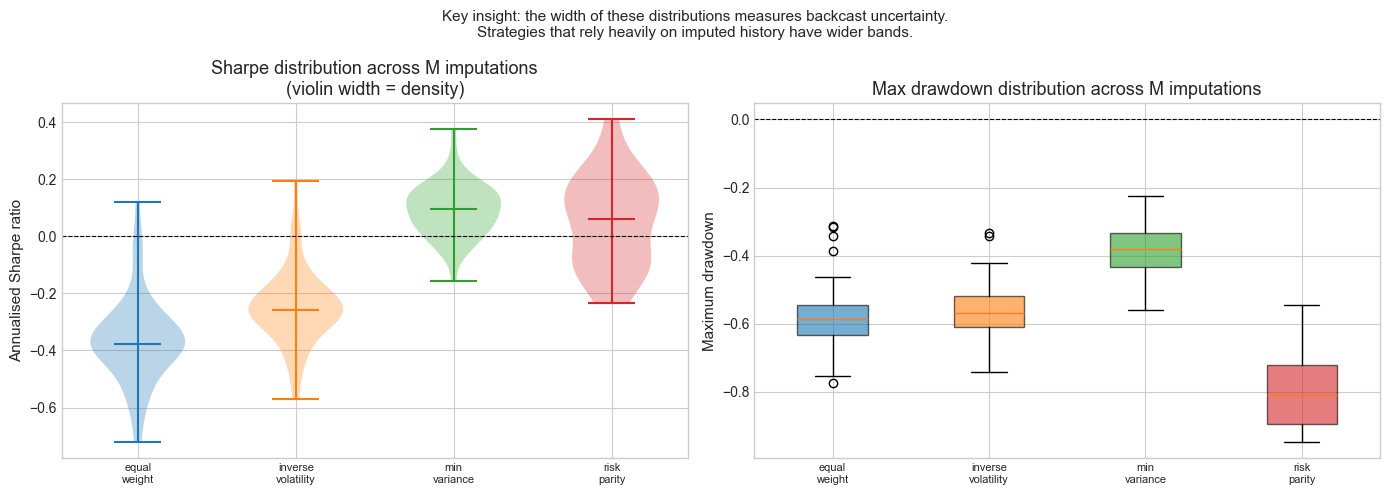

Sharpe 90% CI width by strategy:
  equal_weight            width = 0.529
  risk_parity             width = 0.517
  inverse_volatility      width = 0.450
  min_variance            width = 0.266

Widest CI : equal_weight  — most sensitive to backcast assumptions
Tightest CI: min_variance  — least sensitive to backcast assumptions


In [40]:
# ── Cell 11-4  Sharpe uncertainty insight — wide vs narrow bands ──────────────
if bt_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    palette = plt.cm.tab10.colors

    # Left: Sharpe distributions per strategy
    ax = axes[0]
    for i, (strat, res) in enumerate(bt_results.items()):
        sh = res.sharpe_distribution
        label = f'{strat}\n(med={np.median(sh):+.2f}, iqr={np.percentile(sh,75)-np.percentile(sh,25):.2f})'
        ax.violinplot([sh], positions=[i], showmedians=True,
                      widths=0.6)
    ax.set_xticks(range(len(bt_results)))
    ax.set_xticklabels([s.replace('_', '\n') for s in bt_results], fontsize=8)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('Annualised Sharpe ratio')
    ax.set_title('Sharpe distribution across M imputations\n(violin width = density)')

    # Right: max drawdown distributions
    ax = axes[1]
    mdd_data = [res.max_drawdown_distribution for res in bt_results.values()]
    bp = ax.boxplot(mdd_data, patch_artist=True,
                    labels=[s.replace('_', '\n') for s in bt_results],
                    boxprops=dict(alpha=0.6))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('Maximum drawdown')
    ax.set_title('Max drawdown distribution across M imputations')
    ax.tick_params(axis='x', labelsize=8)

    plt.suptitle(
        'Key insight: the width of these distributions measures backcast uncertainty.\n'
        'Strategies that rely heavily on imputed history have wider bands.',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    # Print the insight
    sharpe_widths = {s: float(np.percentile(r.sharpe_distribution, 95)
                              - np.percentile(r.sharpe_distribution, 5))
                     for s, r in bt_results.items()}
    widest  = max(sharpe_widths, key=sharpe_widths.get)
    tightest= min(sharpe_widths, key=sharpe_widths.get)
    print(f'Sharpe 90% CI width by strategy:')
    for s, w in sorted(sharpe_widths.items(), key=lambda x: -x[1]):
        print(f'  {s:<22}  width = {w:.3f}')
    print(f'\nWidest CI : {widest}  — most sensitive to backcast assumptions')
    print(f'Tightest CI: {tightest}  — least sensitive to backcast assumptions')

## Section 12 — Full Pipeline in One Call

All of the steps above can be orchestrated by a single `BackcastPipeline` object.  Given a YAML config and a CSV path you get back a `FullResults` bundle containing every artefact in one call:

```python
from backcast.pipeline import BackcastPipeline

pipeline = BackcastPipeline(config_path='../config/default_config.yaml')
results  = pipeline.run(csv_path='path/to/returns.csv')
```

When you need finer control — or when your data is already in memory — the pipeline exposes each step as an individual method that you can call in sequence.  The cells below demonstrate both the step-by-step API and how to access the `FullResults` bundle.

In [41]:
# ── Cell 12-1  Step-by-step pipeline on the in-memory dataset ────────────────
from backcast.pipeline import BackcastPipeline, FullResults, DownstreamResults

# Config as a dict — same keys as default_config.yaml
pipeline_cfg = {
    'random_seed': SEED,
    'em':          {'max_iterations': 500, 'tolerance': 1e-8, 'track_loglikelihood': True},
    'kalman':      {'use_smoother': True, 'backcast_beta_method': 'earliest_smoothed'},
    'hmm':         {'n_regimes_candidates': [2, 3, 4], 'selection_criterion': 'bic',
                    'max_iterations': 200, 'tolerance': 1e-4},
    'imputation':  {'n_imputations': 50, 'method': 'unconditional_em'},
    'validation':  {'holdout_days': HOLDOUT_DAYS, 'n_windows': N_WINDOWS,
                    'coverage_level': 0.95},
    'downstream':  {'covariance_shrinkage': True, 'denoise_eigenvalues': True,
                    'uncertainty_confidence': 0.95,
                    'backtest_strategies': ['equal_weight', 'inverse_volatility'],
                    'backtest_lookback': LOOKBACK, 'backtest_rebalance_freq': 21},
    'output':      {'plot_format': 'png', 'plot_dpi': 120, 'save_imputations': False},
}

pipeline = BackcastPipeline(config_dict=pipeline_cfg)
print(f'Pipeline seed: {pipeline.seed}')

# Step 2 — fit all three models
print('\nFitting models ...')
models = pipeline.fit_models(dataset)
print(f"  EM         : converged={models['em'].converged}, iters={models['em'].n_iter}")
print(f"  Kalman     : {'OK' if models['kalman'] else 'skipped'}")
print(f"  HMM        : {'K='+str(models['hmm'].n_regimes) if models['hmm'] else 'skipped'}")

# Step 4 — multiple imputation
print('\nImputing ...')
mi_pipeline = pipeline.impute(dataset, models['em'], models.get('hmm'))
print(f'  {mi_pipeline.n_imputations} imputations  method={mi_pipeline.method}')

# Step 5 — downstream
print('\nComputing downstream ...')
ds_results = pipeline.compute_downstream(dataset, models['em'], mi_pipeline)
print(f'  Covariance shrunk condition number : '
      f'{ds_results.covariance_shrunk.condition_number:.1f}' if ds_results.covariance_shrunk
      else '  Shrinkage skipped')
print(f'  Uncertainty ellipse κ              : {ds_results.ellipsoidal_mu.kappa:.4f}')
print(f'  Backtests run                      : {list(ds_results.backtests.keys())}')

print('\nStep-by-step pipeline complete.')

INFO backcast.pipeline: Pipeline initialised with seed=42
INFO backcast.models.em_stambaugh: EM converged at iteration 14 (ΔΣ = 9.804e-09)
INFO backcast.pipeline: EM: 14 iters, converged=True


Pipeline seed: 42

Fitting models ...


INFO backcast.models.regime_hmm: HMM K=2:  log-L=65287.4  BIC=-130208.6  AIC=-130488.8
INFO backcast.models.regime_hmm: HMM K=3:  log-L=65303.9  BIC=-130028.7  AIC=-130471.9
INFO backcast.models.regime_hmm: HMM K=4:  log-L=65359.8  BIC=-129910.4  AIC=-130529.6
INFO backcast.pipeline: HMM selected K=2 via bic
INFO backcast.imputation.multiple_impute: multiple_impute: 50 imputations drawn (method=unconditional_em, patterns=1)
INFO backcast.downstream.covariance: Ledoit-Wolf shrinkage: alpha = 0.0028


  EM         : converged=True, iters=14
  Kalman     : OK
  HMM        : K=2

Imputing ...
  50 imputations  method=unconditional_em

Computing downstream ...
  Covariance shrunk condition number : 10.5
  Uncertainty ellipse κ              : 3.9379
  Backtests run                      : ['equal_weight', 'inverse_volatility']

Step-by-step pipeline complete.


In [42]:
# ── Cell 12-2  Access results from a FullResults bundle ──────────────────────
# Assemble a FullResults from the objects computed in this notebook
full_results = FullResults(
    dataset       = dataset,
    em_result     = em_result,
    kalman        = kalman_result  if 'kalman_result'  in dir() else None,
    hmm           = hmm_result     if 'hmm_result'     in dir() else None,
    hmm_selection = hmm_selection  if 'hmm_selection'  in dir() else None,
    holdout       = report         if 'report'         in dir() and report is not None else None,
    imputation    = mi_result,
    downstream    = DownstreamResults(
        covariance_em       = cov_results['em'],
        covariance_combined = cov_results['rubin'],
        covariance_shrunk   = cov_results.get('shrunk'),
        covariance_denoised = cov_results.get('denoised'),
        ellipsoidal_mu      = ell,
        box_uncertainty     = box,
        equal_weight_risk   = prd,
        backtests           = bt_results,
    ),
    config        = pipeline_cfg,
)

print('FullResults bundle — field reference')
print('=' * 50)
print(f'results.dataset               BackcastDataset  ({full_results.dataset.n_long}L / {full_results.dataset.n_short}S assets)')
print(f'results.em_result             EMResult         (converged={full_results.em_result.converged}, iters={full_results.em_result.n_iter})')
print(f'results.kalman                KalmanMultiAssetResult  ({("available" if full_results.kalman else "None")})')
print(f'results.hmm                   HMMResult        ({("K="+str(full_results.hmm.n_regimes) if full_results.hmm else "None")})')
print(f'results.holdout               HoldoutReport    (coverage={full_results.holdout.overall_coverage:.1%})')
print(f'results.imputation            MultipleImputationResult  (M={full_results.imputation.n_imputations})')
print()
print('results.downstream:')
print(f'  .covariance_em.covariance          shape {full_results.downstream.covariance_em.covariance.shape}')
print(f'  .covariance_shrunk.condition_number  {full_results.downstream.covariance_shrunk.condition_number:.1f}')
print(f'  .ellipsoidal_mu.kappa              {full_results.downstream.ellipsoidal_mu.kappa:.4f}')
print(f'  .equal_weight_risk.median_risk     {full_results.downstream.equal_weight_risk.median_risk:.6f} (daily)')
print(f'  .backtests.keys()                  {list(full_results.downstream.backtests.keys())}')
print()

# Typical downstream access patterns
print('Common access patterns:')
print('  # Imputed histories (list of M DataFrames):')
print(f'  results.imputation.imputations      → {len(full_results.imputation.imputations)} DataFrames, each {full_results.imputation.imputations[0].shape}')
print('  # Portfolio-ready covariance matrix:')
cov_ready = full_results.downstream.covariance_shrunk or full_results.downstream.covariance_combined
print(f'  results.downstream.covariance_shrunk.covariance  → shape {cov_ready.covariance.shape}')
print('  # Per-strategy backtest Sharpe distribution:')
if full_results.downstream.backtests:
    s0 = next(iter(full_results.downstream.backtests))
    bt0 = full_results.downstream.backtests[s0]
    print(f'  results.downstream.backtests["{s0}"].sharpe_distribution → {len(bt0.sharpe_distribution)} values')

FullResults bundle — field reference
results.dataset               BackcastDataset  (5L / 3S assets)
results.em_result             EMResult         (converged=True, iters=14)
results.kalman                KalmanMultiAssetResult  (available)
results.hmm                   HMMResult        (K=2)
results.holdout               HoldoutReport    (coverage=94.8%)
results.imputation            MultipleImputationResult  (M=50)

results.downstream:
  .covariance_em.covariance          shape (8, 8)
  .covariance_shrunk.condition_number  12.2
  .ellipsoidal_mu.kappa              3.9379
  .equal_weight_risk.median_risk     0.005635 (daily)
  .backtests.keys()                  ['equal_weight', 'inverse_volatility', 'min_variance', 'risk_parity']

Common access patterns:
  # Imputed histories (list of M DataFrames):
  results.imputation.imputations      → 50 DataFrames, each (5000, 8)
  # Portfolio-ready covariance matrix:
  results.downstream.covariance_shrunk.covariance  → shape (8, 8)
  # Per-strat

In [43]:
# ── Cell 12-3  Export results to disk ────────────────────────────────────────
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    artefacts = pipeline.export(full_results, output_dir=tmpdir)
    print(f'Exported {len(artefacts)} artefacts to {tmpdir}/')
    print()
    for name, path in sorted(artefacts.items()):
        size_kb = os.path.getsize(path) / 1024
        print(f'  {name:<30}  {os.path.basename(path):<40}  {size_kb:6.1f} KB')

print()
print('export() always writes:')
print('  01_missingness.png           — missingness heatmap')
print('  02_em_convergence.png        — EM log-likelihood convergence')
print('  03_kalman_betas.png          — smoothed beta time-series (if Kalman fitted)')
print('  04_regime_timeline.png       — HMM regime labels (if HMM fitted)')
print('  05_backcast_fan.png          — multiple-imputation fan chart')
print('  06_correlation_comparison.png— overlap vs backcast correlation matrices')
print('  07_holdout_scatter.png       — actual vs predicted scatter')
print('  09_eigenvalue_spectrum.png   — eigenvalue spectrum with MP bound')
print('  10_uncertainty_ellipse.png   — 2D μ uncertainty ellipse')
print('  11_backtest_<strategy>.png   — fan chart per strategy')
print('  summary.json                 — all key metrics in one JSON file')
print()
print('Set output.save_imputations: true in the config to also save each')
print('imputed history as a Parquet file in imputations/imputation_NNN.parquet.')

INFO backcast.pipeline: Exported 14 artefacts to /var/folders/ch/vz9_k4995d98tx59v0nbf0yc0000gn/T/tmp3ntdzovr


Exported 14 artefacts to /var/folders/ch/vz9_k4995d98tx59v0nbf0yc0000gn/T/tmp3ntdzovr/

  01_missingness                  01_missingness.png                          37.9 KB
  02_em_convergence               02_em_convergence.png                       33.1 KB
  03_kalman_betas                 03_kalman_betas.png                        170.5 KB
  04_regime_timeline              04_regime_timeline.png                      20.7 KB
  05_backcast_fan                 05_backcast_fan.png                        189.2 KB
  06_correlation_comparison       06_correlation_comparison.png               57.7 KB
  07_holdout_scatter              07_holdout_scatter.png                     174.8 KB
  09_eigenvalue_spectrum          09_eigenvalue_spectrum.png                  33.0 KB
  10_uncertainty_ellipse          10_uncertainty_ellipse.png                  31.4 KB
  11_backtest_equal_weight        11_backtest_equal_weight.png               136.6 KB
  11_backtest_inverse_volatility  11_backtest_invers

## Section 13 — Tips & Gotchas

**1. Minimum overlap period.**
You need at least 504 trading days (~2 years) of overlap for stable EM estimates.  With fewer than 252 days the conditional covariance $\Sigma_{M|O}$ will be poorly conditioned and the Kalman betas will be unreliable.  The library enforces `min_overlap_days` in the config (default 504) — set it lower only if you understand the consequences.

**2. Monotone missingness only.**
The library assumes each short-history asset has a single contiguous NaN block at the *start* of its history, then continuous observations.  Mid-series gaps (e.g., a suspended asset) violate this and will raise a `BackcastDataError` at load time.  Handle gaps before calling `build_backcast_dataset` — either by forward-filling prices or by treating the gap as the asset's true start date.

**3. Returns, not prices.**
Input must be daily **simple returns**.  If you have prices, convert first:

```python
returns = prices.pct_change().dropna(how='all')
```

If any single return exceeds ±50%, `load_returns_csv` will warn — that almost always means you accidentally passed prices or log-returns.

**4. Stationarity check via Kalman.**
Always run the Kalman model (Section 4) as a diagnostic.  If any beta drifts by more than ~0.1 over the overlap period, the EM's unconditional estimates may be misleading.  In that case, switch to `method: regime_conditional` in the config, or increase `min_overlap_days` and restrict to the stationary sub-period.

**5. Never use a single backcast path for decisions.**
Single imputation (Section 7) is useful for visualisation and quick checks, but always run multiple imputation (Section 8) before deriving any statistic you plan to act on.  The fan chart and Rubin's confidence intervals exist precisely to show how much trust to place in the backcast.  If the 5–95% band is wide, the result is fragile.

**6. Backcasted returns are model outputs, not data.**
A backtest that includes the imputed period is answering the question: *"how would a strategy with these assets' overlap-period statistical properties have performed given the factor returns of the earlier period?"*  It does **not** tell you what the assets would have actually returned.  Always label imputed-period results clearly and report the Sharpe uncertainty bands alongside the point estimate.